# Phase 6 & 7: Model Training, Hyperparameter Tuning, and Stacking Ensemble

This notebook guides you through:
1. **Loading Preprocessed Splits**: Loading the resampled training set and clean test set saved in the previous SMOTE notebook.
2. **Hyperparameter Tuning**: Tuning Extra Trees and LightGBM using randomized search on a small balanced training subset.
3. **Base Model Training**: Fitting Random Forest, Extra Trees, and LightGBM on the full balanced dataset.
4. **Stacking Ensemble**: Combining predictions using a Logistic Regression meta-learner.
5. **Save Trained Models**: Saving the ensemble and individual classifiers using `joblib`.
6. **Evaluation**: Calculating F1-score, Precision, Recall, Accuracy, and saving Normalized Confusion Matrices.

06_Model_Training.ipynb

Cell 1
Import Libraries

Cell 2
Project Directories

Cell 3
Load Balanced Dataset

Cell 4
Dataset Information

Cell 5
Train Random Forest

Cell 6
Evaluate RF

Cell 7
Save RF

Cell 8
Train Extra Trees

Cell 9
Evaluate ET

Cell 10
Save ET

Cell 11
Train LightGBM

Cell 12
Evaluate LGBM

Cell 13
Save LGBM

Cell 14
Train XGBoost

Cell 15
Evaluate XGB

Cell 16
Save XGB

Cell 17
Performance Comparison

Cell 18
Save Metrics

In [ ]:
# Load cached best parameters if skipping tuning cell
params_file = REPORTS_DIR / "best_params.json"
if params_file.exists():
    with open(params_file, "r") as f:
        best_params = json.load(f)
else:
    best_params = {"et": None, "lgbm": None}

base_models = train_base_models(
    X_train_final, 
    y_train_final, 
    best_params_et=best_params["et"], 
    best_params_lgbm=best_params["lgbm"]
)

In [2]:
packages = {
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "sklearn": "sklearn",
    "imblearn": "imblearn"
}

for pkg, imp in packages.items():
    try:
        __import__(imp)
        print(f"✅ {pkg}")
    except ImportError:
        print(f"❌ {pkg}")

❌ lightgbm
❌ xgboost
✅ sklearn
✅ imblearn


In [3]:
%pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 11.0 MB/s eta 0:00:0000:010:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
print(sys.executable)

/opt/tljh/user/bin/python


In [5]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 25.9 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install lightgbm xgboost shap catboost

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 44.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 25.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 13.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 10.6 MB/s eta 0:00:00a 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [7]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from pathlib import Path

import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from lightgbm import LGBMClassifier

from xgboost import XGBClassifier

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [8]:
# ==========================================================
# PROJECT DIRECTORY
# ==========================================================

PROJECT_DIR = Path.cwd().parent

DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"

MODEL_DIR = PROJECT_DIR / "models"

RESULT_DIR = PROJECT_DIR / "results"

MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

print(PROJECT_DIR)

/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System


In [9]:
# ==========================================================
# LOAD DATASET
# ==========================================================

X_train = pd.read_parquet(DATASET_DIR / "X_train_smote.parquet")

y_train = pd.read_parquet(DATASET_DIR / "y_train_smote.parquet")

X_test = pd.read_parquet(DATASET_DIR / "X_test.parquet")

y_test = pd.read_parquet(DATASET_DIR / "y_test.parquet")

# Convert labels to Series
y_train = y_train["Label"]
y_test = y_test["Label"]

print("=" * 70)
print("Datasets Loaded Successfully")
print("=" * 70)

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print()

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

Datasets Loaded Successfully
X_train : (3249922, 30)
y_train : (3249922,)

X_test : (397985, 30)
y_test : (397985,)


In [10]:
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print("Training Samples :", len(X_train))

print("Testing Samples :", len(X_test))

print("Number of Features :", X_train.shape[1])

print()

print("Feature Names")

print(list(X_train.columns))

DATASET SUMMARY
Training Samples : 3249922
Testing Samples : 397985
Number of Features : 30

Feature Names
['Fwd IAT Std', 'Bwd IAT Min', 'Flow IAT Min', 'Bwd Packet Length Std', 'Bwd Packet Length Mean', 'Avg Bwd Segment Size', 'Idle Min', 'Bwd Packet Length Max', 'Idle Mean', 'Packet Length Std', 'Idle Max', 'Flow IAT Max', 'Max Packet Length', 'Fwd IAT Max', 'Packet Length Variance', 'Average Packet Size', 'Packet Length Mean', 'Active Min', 'FIN Flag Count', 'Active Std', 'Flow IAT Std', 'PSH Flag Count', 'Active Mean', 'Fwd IAT Total', 'ACK Flag Count', 'Flow Duration', 'Bwd IAT Std', 'Subflow Fwd Bytes', 'Flow IAT Mean', 'Min Packet Length']


In [11]:
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path.cwd().parent

DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"

X_train = pd.read_csv(DATASET_DIR / "X_train_smote.csv")
y_train = pd.read_csv(DATASET_DIR / "y_train_smote.csv").squeeze()

X_test = pd.read_csv(DATASET_DIR / "X_test.csv")
y_test = pd.read_csv(DATASET_DIR / "y_test.csv").squeeze()

print("="*70)
print("Datasets Loaded Successfully")
print("="*70)

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

Datasets Loaded Successfully
X_train : (19854300, 30)
y_train : (19854300,)
X_test  : (397985, 30)
y_test  : (397985,)


In [16]:
print("=" * 70)
print("TRAINING RANDOM FOREST")
print("=" * 70)

import time

start = time.time()

rf = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    n_jobs=-1,

    verbose=1

)

rf.fit(X_train, y_train)

end = time.time()

print()

print(f"Training Completed in {(end-start)/60:.2f} Minutes")

TRAINING RANDOM FOREST


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 128 concurrent workers.


KeyboardInterrupt: 

In [17]:
print(X_train_smote.shape)
print(y_train_smote.shape)

NameError: name 'X_train_smote' is not defined

In [18]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent
DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"

for file in DATASET_DIR.iterdir():
    print(file.name)

X_test.parquet
X_train.parquet
X_test.csv
y_train_smote.parquet
.ipynb_checkpoints
y_train.parquet
X_train_smote.parquet
y_test.csv
selected_features_clean.csv
y_test.parquet
selected_features.csv


In [19]:
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path.cwd().parent
DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"

X_train_smote = pd.read_parquet(DATASET_DIR / "X_train_smote.parquet")
y_train_smote = pd.read_parquet(DATASET_DIR / "y_train_smote.parquet").iloc[:, 0]

X_test = pd.read_parquet(DATASET_DIR / "X_test.parquet")
y_test = pd.read_parquet(DATASET_DIR / "y_test.parquet").iloc[:, 0]

print("="*70)
print("Datasets Loaded Successfully")
print("="*70)

print("X_train_smote :", X_train_smote.shape)
print("y_train_smote :", y_train_smote.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

Datasets Loaded Successfully
X_train_smote : (2563626, 30)
y_train_smote : (2563626,)
X_test : (397985, 30)
y_test : (397985,)


In [20]:
print("=" * 70)
print("TRAINING RANDOM FOREST")
print("=" * 70)

import time
from sklearn.ensemble import RandomForestClassifier

start = time.time()

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf.fit(X_train_smote, y_train_smote)

end = time.time()

print("\n" + "=" * 70)
print("RANDOM FOREST TRAINING COMPLETED")
print("=" * 70)
print(f"Training Time : {(end-start)/60:.2f} minutes")

TRAINING RANDOM FOREST


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 128 concurrent workers.



RANDOM FOREST TRAINING COMPLETED
Training Time : 0.87 minutes


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   51.7s finished


In [21]:
print("=" * 70)
print("RANDOM FOREST PREDICTION")
print("=" * 70)

import time

start = time.time()

rf_pred = rf.predict(X_test)

end = time.time()

print(f"Prediction Time : {end-start:.2f} seconds")

RANDOM FOREST PREDICTION


[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.


Prediction Time : 5.14 seconds


[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:    4.9s finished


In [22]:
print("=" * 70)
print("RANDOM FOREST PERFORMANCE")
print("=" * 70)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, rf_pred)
precision = precision_score(y_test, rf_pred, average='weighted')
recall = recall_score(y_test, rf_pred, average='weighted')
f1 = f1_score(y_test, rf_pred, average='weighted')

print(f"Accuracy  : {accuracy:.6f}")
print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"F1 Score  : {f1:.6f}")

RANDOM FOREST PERFORMANCE
Accuracy  : 0.996397
Precision : 0.996733
Recall    : 0.996397
F1 Score  : 0.996529


In [24]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path.cwd().parent
DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"

df = pd.read_csv(DATASET_DIR / "selected_features_clean.csv")

label_encoder = LabelEncoder()
label_encoder.fit(df["Label"])

print(label_encoder.classes_)

['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [25]:
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=label_encoder.classes_
    )
)

CLASSIFICATION REPORT
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    330906
                       Bot       0.60      0.88      0.72       268
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.94      0.99      0.97      2056
                  DoS Hulk       0.99      0.99      0.99     34399
          DoS Slowhttptest       0.93      0.99      0.96      1045
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       0.98      0.99      0.99      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.88      0.93      0.91       385
               SSH-Patator       0.90      0.95      0.93       631
  Web Attack � Brute Force       0.67      0.61      0.64       285
Web Attack � Sql Injectio

CONFUSION MATRIX


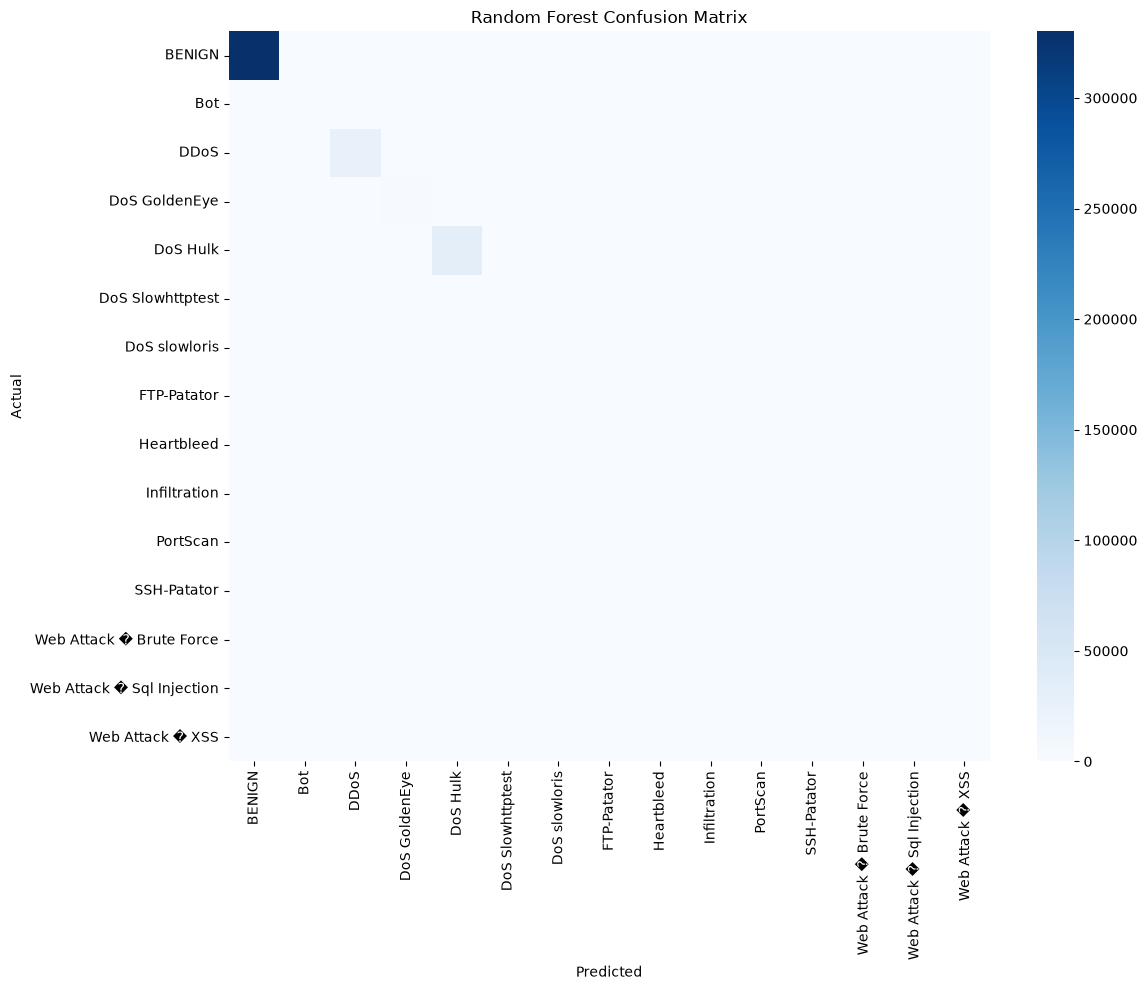

In [26]:
print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()

Confusion Matrix Saved Successfully
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/figures/random_forest_confusion_matrix.png


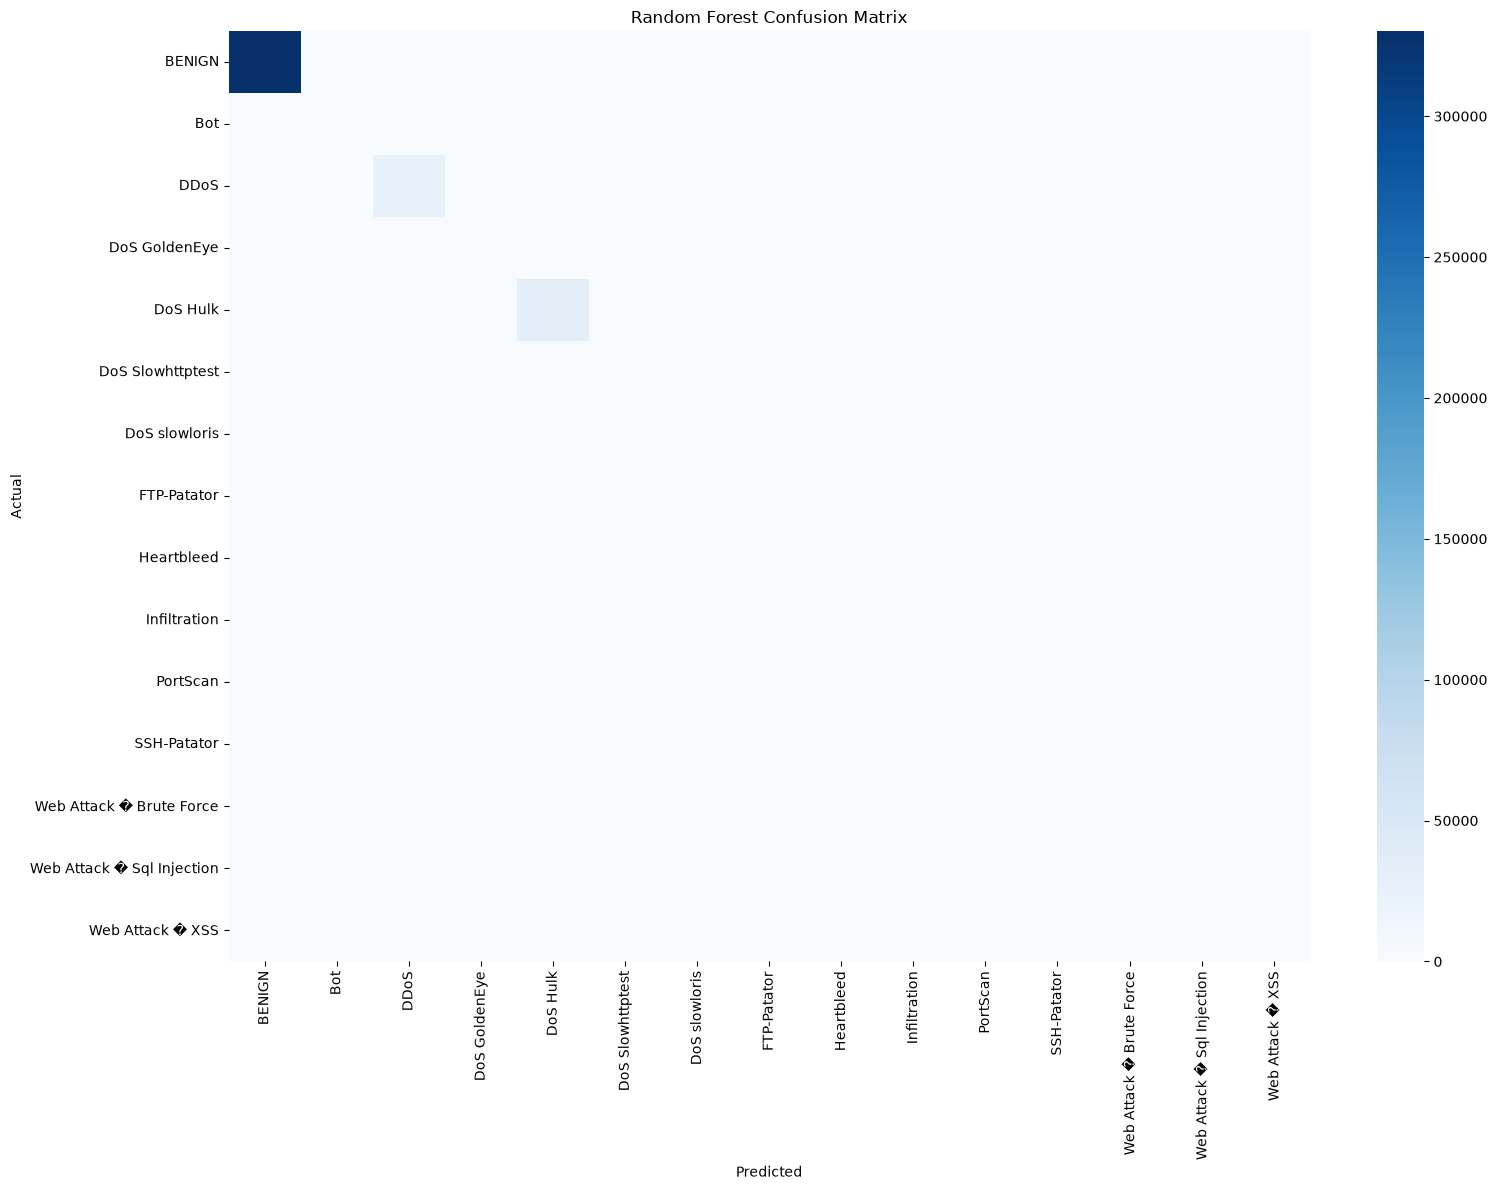

In [32]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --------------------------------------------------
# Create Results Folder
# --------------------------------------------------

PROJECT_DIR = Path.cwd().parent

RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Confusion Matrix
# --------------------------------------------------

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(16, 12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# --------------------------------------------------
# Save Figure
# --------------------------------------------------

save_path = FIGURES_DIR / "random_forest_confusion_matrix.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

print("="*70)
print("Confusion Matrix Saved Successfully")
print("="*70)
print(save_path)

plt.show()

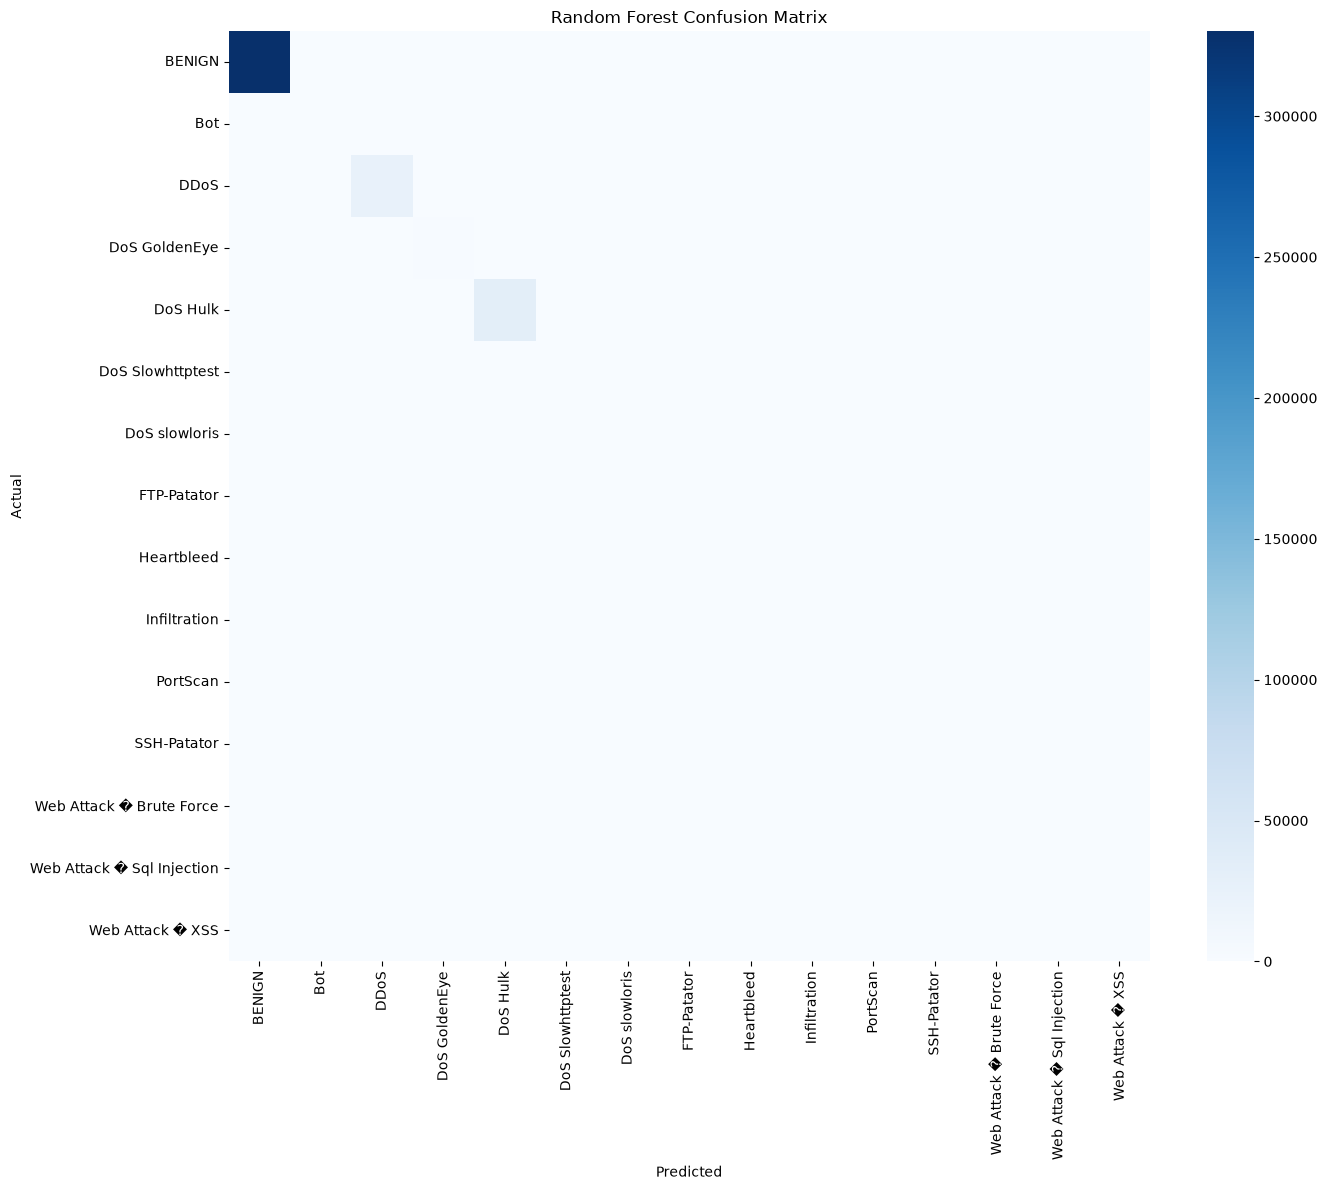

Saved Successfully!
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/figures/random_forest_confusion_matrix.png


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path

# Get confusion matrix
cm = confusion_matrix(y_test, rf_pred)

# Create results/figures folder
FIGURE_DIR = PROJECT_DIR / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

# Save figure
plt.savefig(FIGURE_DIR / "random_forest_confusion_matrix.png", dpi=300)

plt.show()

print("Saved Successfully!")
print(FIGURE_DIR / "random_forest_confusion_matrix.png")

In [34]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    rf_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_path = RESULTS_DIR / "random_forest_classification_report.csv"

report_df.to_csv(report_path)

print("Classification Report Saved")
print(report_path)

Classification Report Saved
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/random_forest_classification_report.csv


In [30]:
print("rf" in globals())
print("rf_pred" in globals())
print("y_test" in globals())
print("class_names" in globals())

True
True
True
False


In [31]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load original dataset
df = pd.read_csv(PROJECT_DIR / "dataset" / "cleaned" / "selected_features_clean.csv")

label_encoder = LabelEncoder()
label_encoder.fit(df["Label"])

class_names = label_encoder.classes_

print(class_names)

['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [35]:
print("rf :", "rf" in globals())
print("rf_pred :", "rf_pred" in globals())
print("y_test :", "y_test" in globals())
print("PROJECT_DIR :", "PROJECT_DIR" in globals())

rf : True
rf_pred : True
y_test : True
PROJECT_DIR : True


In [36]:
from pathlib import Path

MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Model Directory:", MODEL_DIR)

Model Directory: /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models


In [37]:
import joblib

model_path = MODEL_DIR / "random_forest_model.pkl"

joblib.dump(rf, model_path)

print("=" * 70)
print("RANDOM FOREST MODEL SAVED")
print("=" * 70)
print("Location:", model_path)

RANDOM FOREST MODEL SAVED
Location: /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models/random_forest_model.pkl


In [38]:
class_names = sorted(y_test.unique())

joblib.dump(class_names, MODEL_DIR / "class_names.pkl")

print("Class names saved successfully.")

Class names saved successfully.


In [39]:
import os

print("=" * 70)
print("FILES INSIDE MODELS FOLDER")
print("=" * 70)

for file in os.listdir(MODEL_DIR):
    print(file)

FILES INSIDE MODELS FOLDER
class_names.pkl
.gitkeep
label_encoder.pkl
random_forest_model.pkl


In [40]:
print("=" * 70)
print("SAVING FEATURE IMPORTANCE")
print("=" * 70)

importance_df = (
    pd.DataFrame({
        "Feature": X_train_smote.columns,
        "Importance": rf.feature_importances_
    })
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance_df.to_csv(
    RESULTS_DIR / "RandomForest_FeatureImportance.csv",
    index=False
)

importance_df.head(20)

SAVING FEATURE IMPORTANCE


,Feature,Importance
4,Bwd Packet Length Mean,0.058851
5,Avg Bwd Segment Size,0.055298
27,Subflow Fwd Bytes,0.054846
13,Fwd IAT Max,0.050950
3,Bwd Packet Length Std,0.050157
28,Flow IAT Mean,0.048973
7,Bwd Packet Length Max,0.048579
23,Fwd IAT Total,0.047509
11,Flow IAT Max,0.046898
25,Flow Duration,0.043389


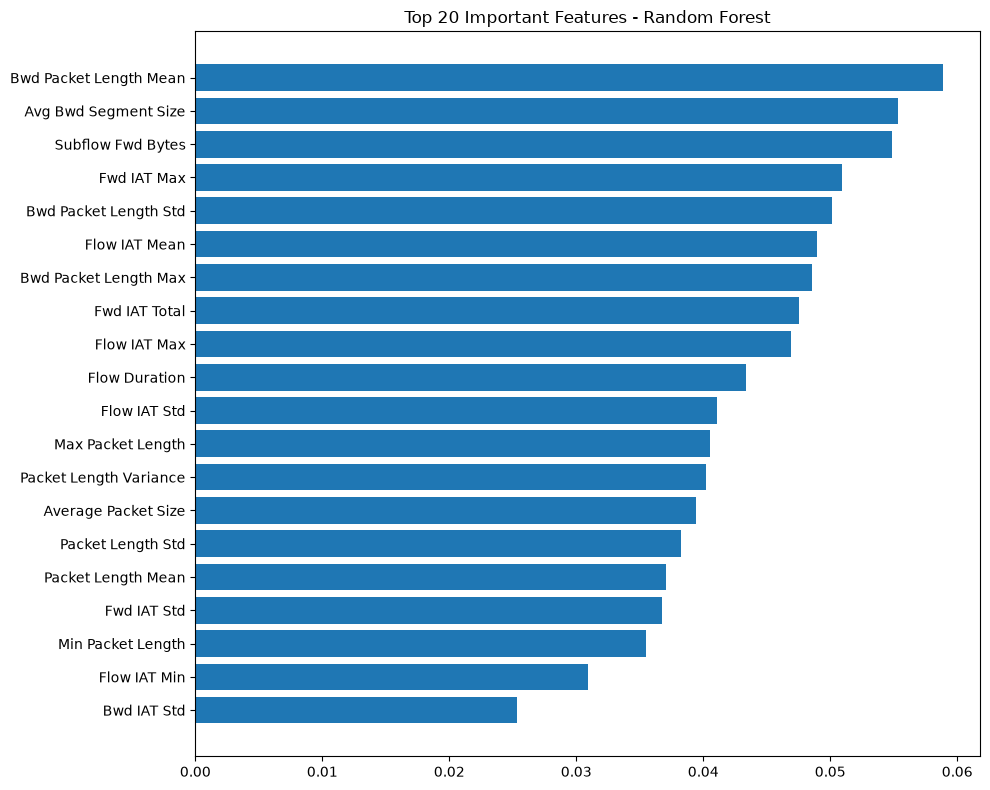

In [41]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features - Random Forest")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "RandomForest_FeatureImportance.png",
    dpi=300
)

plt.show()

In [45]:
import time

prediction_start = time.time()

rf_pred = rf.predict(X_test)

prediction_end = time.time()

prediction_time = prediction_end - prediction_start

print(f"Prediction Time: {prediction_time:.2f} seconds")

[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.


Prediction Time: 4.84 seconds


[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:    4.6s finished


In [46]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "Training Time (min)": [round((end - start) / 60, 2)],
    "Prediction Time (sec)": [round(prediction_time, 2)]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (min),Prediction Time (sec)
0,Random Forest,0.996397,0.996733,0.996397,0.996529,0.09,4.84


In [47]:
comparison_df.to_csv(
    RESULTS_DIR / "Model_Comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [48]:
print("=" * 70)
print("TRAINING EXTRA TREES")
print("=" * 70)

import time
from sklearn.ensemble import ExtraTreesClassifier

training_start = time.time()

et = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

et.fit(X_train_smote, y_train_smote)

training_end = time.time()

training_time = (training_end - training_start) / 60

print("\nTraining Completed!")
print(f"Training Time : {training_time:.2f} minutes")

TRAINING EXTRA TREES


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 128 concurrent workers.



Training Completed!
Training Time : 0.38 minutes


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   21.6s finished


In [49]:
print("=" * 70)
print("EXTRA TREES PREDICTION")
print("=" * 70)

import time

prediction_start = time.time()

et_pred = et.predict(X_test)

prediction_end = time.time()

et_prediction_time = prediction_end - prediction_start

print(f"Prediction Time : {et_prediction_time:.2f} seconds")

EXTRA TREES PREDICTION


[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.


Prediction Time : 6.28 seconds


[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:    6.1s finished


In [50]:
print("=" * 70)
print("EXTRA TREES PERFORMANCE")
print("=" * 70)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

et_accuracy = accuracy_score(y_test, et_pred)

et_precision = precision_score(
    y_test,
    et_pred,
    average="weighted"
)

et_recall = recall_score(
    y_test,
    et_pred,
    average="weighted"
)

et_f1 = f1_score(
    y_test,
    et_pred,
    average="weighted"
)

print(f"Accuracy  : {et_accuracy:.6f}")
print(f"Precision : {et_precision:.6f}")
print(f"Recall    : {et_recall:.6f}")
print(f"F1 Score  : {et_f1:.6f}")

EXTRA TREES PERFORMANCE
Accuracy  : 0.996417
Precision : 0.996731
Recall    : 0.996417
F1 Score  : 0.996538


In [54]:
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    et_pred,
    target_names=class_names
)

print(report)

with open(
    RESULTS_DIR / "ExtraTrees_Classification_Report.txt",
    "w"
) as f:
    f.write(report)

CLASSIFICATION REPORT
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    330906
                       Bot       0.61      0.87      0.72       268
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.95      0.99      0.97      2056
                  DoS Hulk       0.99      0.99      0.99     34399
          DoS Slowhttptest       0.93      0.99      0.96      1045
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       0.98      0.99      0.99      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.80      0.57      0.67         7
                  PortScan       0.88      0.93      0.91       385
               SSH-Patator       0.90      0.95      0.93       631
  Web Attack � Brute Force       0.71      0.61      0.66       285
Web Attack � Sql Injectio

In [52]:
print(class_names)
print(type(class_names[0]))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
<class 'numpy.int64'>


In [53]:
import joblib

label_encoder = joblib.load(MODEL_DIR / "label_encoder.pkl")

class_names = label_encoder.classes_

print(class_names)

['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [55]:
print("=" * 70)
print("EXTRA TREES PREDICTION")
print("=" * 70)

import time

prediction_start = time.time()

et_pred = et.predict(X_test)

prediction_end = time.time()

et_prediction_time = prediction_end - prediction_start

print(f"Prediction Time : {et_prediction_time:.2f} seconds")

EXTRA TREES PREDICTION


[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.


Prediction Time : 5.76 seconds


[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:    5.6s finished


In [56]:
print("=" * 70)
print("EXTRA TREES PERFORMANCE")
print("=" * 70)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

et_accuracy = accuracy_score(y_test, et_pred)

et_precision = precision_score(
    y_test,
    et_pred,
    average="weighted"
)

et_recall = recall_score(
    y_test,
    et_pred,
    average="weighted"
)

et_f1 = f1_score(
    y_test,
    et_pred,
    average="weighted"
)

print(f"Accuracy  : {et_accuracy:.6f}")
print(f"Precision : {et_precision:.6f}")
print(f"Recall    : {et_recall:.6f}")
print(f"F1 Score  : {et_f1:.6f}")

EXTRA TREES PERFORMANCE
Accuracy  : 0.996417
Precision : 0.996731
Recall    : 0.996417
F1 Score  : 0.996538


In [57]:
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    et_pred,
    target_names=class_names
)

print(report)

with open(
    RESULTS_DIR / "ExtraTrees_Classification_Report.txt",
    "w"
) as f:
    f.write(report)

CLASSIFICATION REPORT
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    330906
                       Bot       0.61      0.87      0.72       268
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.95      0.99      0.97      2056
                  DoS Hulk       0.99      0.99      0.99     34399
          DoS Slowhttptest       0.93      0.99      0.96      1045
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       0.98      0.99      0.99      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.80      0.57      0.67         7
                  PortScan       0.88      0.93      0.91       385
               SSH-Patator       0.90      0.95      0.93       631
  Web Attack � Brute Force       0.71      0.61      0.66       285
Web Attack � Sql Injectio

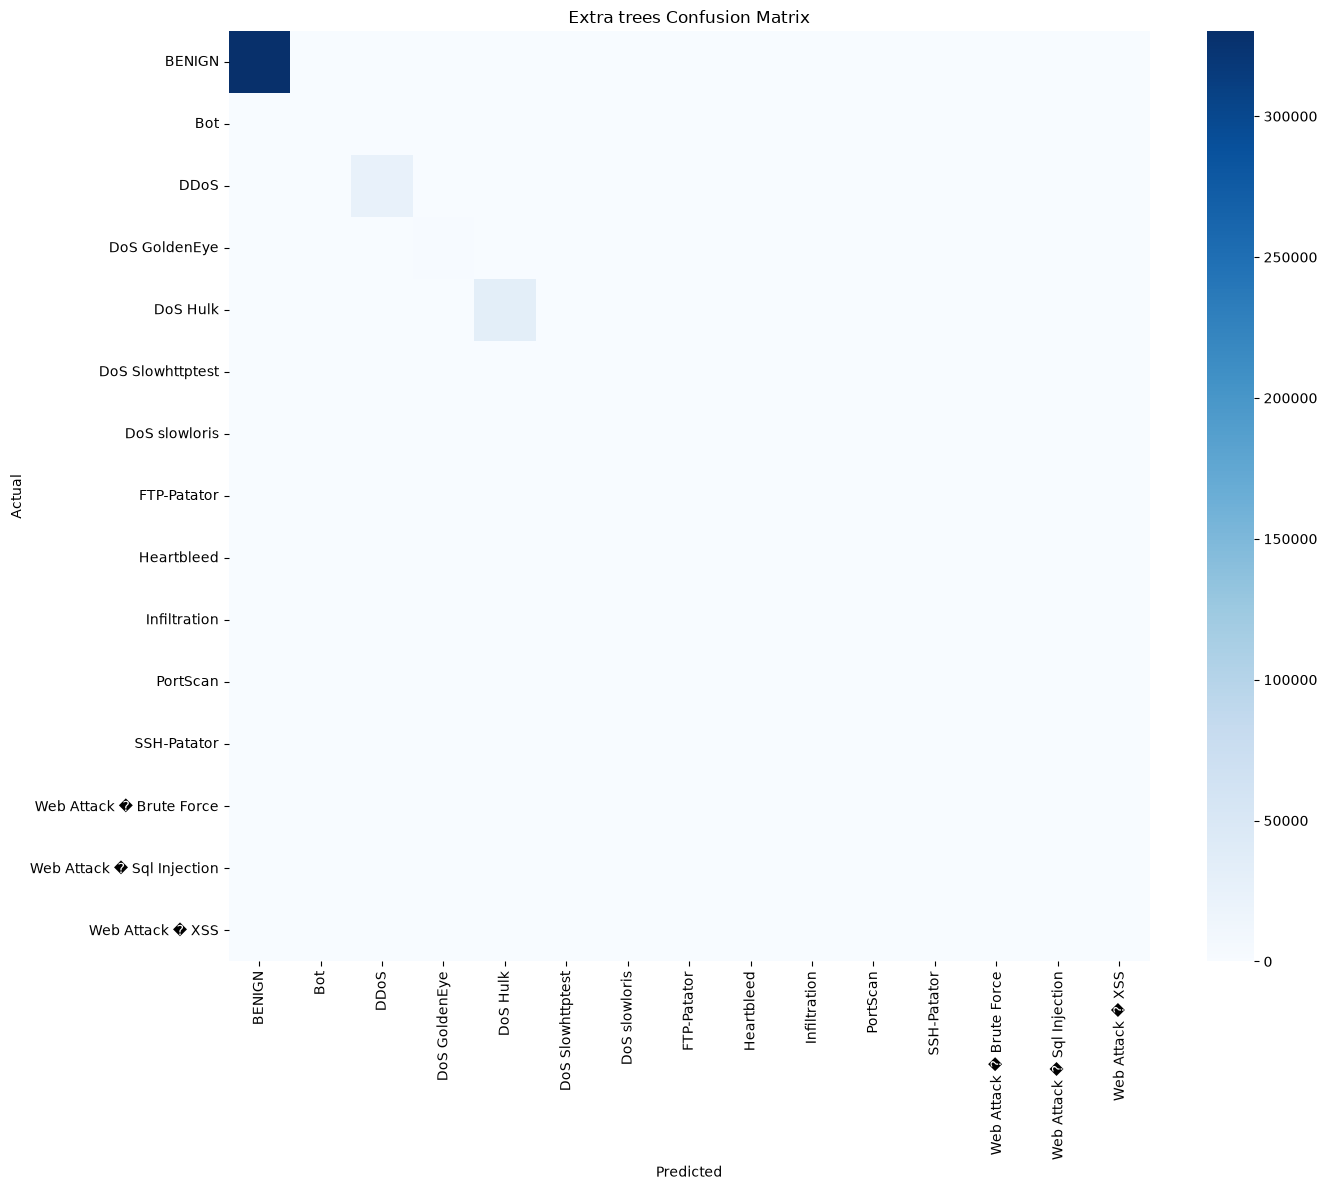

Saved Successfully!
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/figures/extra_tree_confusion_matrix.png


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path

# Get confusion matrix
cm = confusion_matrix(y_test, et_pred)

# Create results/figures folder
FIGURE_DIR = PROJECT_DIR / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Extra trees Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

# Save figure
plt.savefig(FIGURE_DIR / "extra_tree_confusion_matrix.png", dpi=300)

plt.show()

print("Saved Successfully!")
print(FIGURE_DIR / "extra_tree_confusion_matrix.png")

In [59]:
importance_df = (
    pd.DataFrame({
        "Feature": X_train_smote.columns,
        "Importance": et.feature_importances_
    })
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance_df.to_csv(
    RESULTS_DIR /
    "ExtraTrees_FeatureImportance.csv",
    index=False
)

In [1]:
from lightgbm import LGBMClassifier
import time

In [4]:
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path.cwd().parent

DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"
MODEL_DIR = PROJECT_DIR / "models"
RESULT_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULT_DIR / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LOADING DATASETS")
print("=" * 70)

X_train = pd.read_parquet(DATASET_DIR / "X_train.parquet")
y_train = pd.read_parquet(DATASET_DIR / "y_train_smote.parquet").squeeze()

X_test = pd.read_parquet(DATASET_DIR / "X_test.parquet")
y_test = pd.read_parquet(DATASET_DIR / "y_test.parquet").squeeze()

print("Datasets Loaded Successfully\n")

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

LOADING DATASETS
Datasets Loaded Successfully

X_train : (1591936, 30)
y_train : (2563626,)
X_test  : (397985, 30)
y_test  : (397985,)


In [6]:
from pathlib import Path
import pandas as pd

DATASET_DIR = Path.cwd().parent / "dataset" / "cleaned"

for file in DATASET_DIR.iterdir():
    if file.suffix == ".parquet":
        try:
            df = pd.read_parquet(file)
            print(f"{file.name:25} -> {df.shape}")
        except Exception as e:
            print(file.name, e)

X_test.parquet            -> (397985, 30)
X_train.parquet           -> (1591936, 30)
y_train_smote.parquet     -> (2563626, 1)
y_train.parquet           -> (1591936, 1)
X_train_smote.parquet     -> (2563626, 30)
y_test.parquet            -> (397985, 1)


In [7]:
X_train = pd.read_parquet(DATASET_DIR / "X_train_smote.parquet")
y_train = pd.read_parquet(DATASET_DIR / "y_train_smote.parquet").squeeze()

In [8]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2563626, 30)
(2563626,)
(397985, 30)
(397985,)


In [11]:
print("=" * 70)
print("TRAINING LIGHTGBM")
print("=" * 70)

start = time.time()

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=10,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(X_train, y_train)

end = time.time()

lgbm_train_time = end - start

print()
print("=" * 70)
print("LIGHTGBM TRAINING COMPLETED")
print("=" * 70)
print(f"Training Time : {lgbm_train_time/60:.2f} minutes")

TRAINING LIGHTGBM

LIGHTGBM TRAINING COMPLETED
Training Time : 47.47 minutes


In [10]:
import psutil

memory = psutil.virtual_memory()
print(f"Total RAM: {memory.total / (1024**3):.2f} GB")
print(f"Available RAM: {memory.available / (1024**3):.2f} GB")
print(f"Used RAM: {memory.percent}%")


Total RAM: 503.53 GB
Available RAM: 420.43 GB
Used RAM: 16.5%


In [12]:
print(X_train.dtypes)

Fwd IAT Std               float64
Bwd IAT Min                 int64
Flow IAT Min                int64
Bwd Packet Length Std     float64
Bwd Packet Length Mean    float64
Avg Bwd Segment Size      float64
Idle Min                    int64
Bwd Packet Length Max       int64
Idle Mean                 float64
Packet Length Std         float64
Idle Max                    int64
Flow IAT Max                int64
Max Packet Length           int64
Fwd IAT Max                 int64
Packet Length Variance    float64
Average Packet Size       float64
Packet Length Mean        float64
Active Min                  int64
FIN Flag Count              int64
Active Std                float64
Flow IAT Std              float64
PSH Flag Count              int64
Active Mean               float64
Fwd IAT Total               int64
ACK Flag Count              int64
Flow Duration               int64
Bwd IAT Std               float64
Subflow Fwd Bytes           int64
Flow IAT Mean             float64
Min Packet Len

In [13]:
X_train.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 2563626 entries, 0 to 2563625
Data columns (total 30 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Fwd IAT Std             float64
 1   Bwd IAT Min             int64  
 2   Flow IAT Min            int64  
 3   Bwd Packet Length Std   float64
 4   Bwd Packet Length Mean  float64
 5   Avg Bwd Segment Size    float64
 6   Idle Min                int64  
 7   Bwd Packet Length Max   int64  
 8   Idle Mean               float64
 9   Packet Length Std       float64
 10  Idle Max                int64  
 11  Flow IAT Max            int64  
 12  Max Packet Length       int64  
 13  Fwd IAT Max             int64  
 14  Packet Length Variance  float64
 15  Average Packet Size     float64
 16  Packet Length Mean      float64
 17  Active Min              int64  
 18  FIN Flag Count          int64  
 19  Active Std              float64
 20  Flow IAT Std            float64
 21  PSH Flag Count          int64  
 22  Activ

In [14]:
prediction_start = time.time()

lgbm_pred = lgbm.predict(X_test)

prediction_end = time.time()

lgbm_prediction_time = prediction_end - prediction_start

print(f"Prediction Time : {lgbm_prediction_time:.2f} seconds")

Prediction Time : 1.62 seconds


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lgbm_accuracy = accuracy_score(y_test, lgbm_pred)
lgbm_precision = precision_score(y_test, lgbm_pred, average="weighted")
lgbm_recall = recall_score(y_test, lgbm_pred, average="weighted")
lgbm_f1 = f1_score(y_test, lgbm_pred, average="weighted")

print("Accuracy :", lgbm_accuracy)
print("Precision:", lgbm_precision)
print("Recall   :", lgbm_recall)
print("F1 Score :", lgbm_f1)

Accuracy : 0.8707966380642487
Precision: 0.9485524085030489
Recall   : 0.8707966380642487
F1 Score : 0.9047446823239377


In [17]:
import joblib

joblib.dump(
    lgbm,
    MODEL_DIR / "lightgbm_model.pkl"
)

print("=" * 70)
print("LightGBM Model Saved Successfully")
print("=" * 70)

LightGBM Model Saved Successfully


In [19]:
import joblib

label_encoder = joblib.load(MODEL_DIR / "label_encoder.pkl")

class_names = label_encoder.classes_

print(class_names)

['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [20]:
import pandas as pd
import joblib
from pathlib import Path

PROJECT_DIR = Path.cwd().parent

DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"
MODEL_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"

# Load datasets
X_train = pd.read_parquet(DATASET_DIR / "X_train_smote.parquet")
y_train = pd.read_parquet(DATASET_DIR / "y_train_smote.parquet").squeeze()

X_test = pd.read_parquet(DATASET_DIR / "X_test.parquet")
y_test = pd.read_parquet(DATASET_DIR / "y_test.parquet").squeeze()

# Load Label Encoder
label_encoder = joblib.load(MODEL_DIR / "label_encoder.pkl")
class_names = label_encoder.classes_

print("Everything loaded successfully!")

Everything loaded successfully!


In [21]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    lgbm_pred,
    target_names=class_names
)

print(report)

with open(
    RESULTS_DIR / "LightGBM_Classification_Report.txt",
    "w"
) as f:
    f.write(report)

print("Classification Report Saved!")

                            precision    recall  f1-score   support

                    BENIGN       0.98      0.90      0.93    330906
                       Bot       0.03      0.60      0.05       268
                      DDoS       0.84      0.68      0.75     25603
             DoS GoldenEye       0.36      0.77      0.49      2056
                  DoS Hulk       0.92      0.79      0.85     34399
          DoS Slowhttptest       0.12      0.64      0.21      1045
             DoS slowloris       0.46      0.60      0.52      1077
               FTP-Patator       0.12      0.90      0.22      1187
                Heartbleed       0.02      1.00      0.04         2
              Infiltration       0.00      0.29      0.00         7
                  PortScan       0.05      0.67      0.09       385
               SSH-Patator       0.27      0.92      0.41       631
  Web Attack � Brute Force       0.03      0.41      0.06       285
Web Attack � Sql Injection       0.00      0.50

In [22]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (min)",
        "Prediction Time (sec)"
    ],
    "Value": [
        lgbm_accuracy,
        lgbm_precision,
        lgbm_recall,
        lgbm_f1,
        round(lgbm_train_time / 60, 2),
        round(lgbm_prediction_time, 2)
    ]
})

metrics_df.to_csv(
    RESULTS_DIR / "LightGBM_Metrics.csv",
    index=False
)

print("Metrics Saved!")

Metrics Saved!


In [23]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.to_csv(
    RESULTS_DIR / "LightGBM_FeatureImportance.csv",
    index=False
)

print("Feature Importance Saved!")

Feature Importance Saved!


In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, lgbm_pred)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "LightGBM_ConfusionMatrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Confusion Matrix Saved!")

Confusion Matrix Saved!


In [26]:
import pandas as pd

comparison_df = pd.read_csv(
    RESULTS_DIR / "Model_Comparison.csv"
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (min),Prediction Time (sec)
0,Random Forest,0.996397,0.996733,0.996397,0.996529,0.090000,4.840000
1,Extra Trees,0.996417,0.996731,0.996417,0.996538,0.378098,5.755995


In [27]:
new_row = pd.DataFrame({
    "Model": ["LightGBM"],
    "Accuracy": [lgbm_accuracy],
    "Precision": [lgbm_precision],
    "Recall": [lgbm_recall],
    "F1 Score": [lgbm_f1],
    "Training Time (min)": [round(lgbm_train_time / 60, 2)],
    "Prediction Time (sec)": [round(lgbm_prediction_time, 2)]
})

comparison_df = pd.concat(
    [comparison_df, new_row],
    ignore_index=True
)

comparison_df.to_csv(
    RESULTS_DIR / "Model_Comparison.csv",
    index=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (min),Prediction Time (sec)
0,Random Forest,0.996397,0.996733,0.996397,0.996529,0.090000,4.840000
1,Extra Trees,0.996417,0.996731,0.996417,0.996538,0.378098,5.755995
2,LightGBM,0.870797,0.948552,0.870797,0.904745,47.470000,1.620000


In [28]:
import os

print(os.path.exists(RESULTS_DIR / "Model_Comparison.csv"))

True


In [29]:
import xgboost

print(xgboost.__version__)

3.4.0


In [2]:
print("=" * 70)
print("IMPORTING LIBRARIES")
print("=" * 70)

import time
import joblib
import pandas as pd

from xgboost import XGBClassifier

IMPORTING LIBRARIES


In [1]:
print("=" * 70)
print("TRAINING XGBOOST")
print("=" * 70)

start = time.time()

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

end = time.time()

xgb_train_time = end - start

print()
print("=" * 70)
print("XGBOOST TRAINING COMPLETED")
print("=" * 70)
print(f"Training Time : {xgb_train_time/60:.2f} minutes")

TRAINING XGBOOST


NameError: name 'time' is not defined

In [2]:
print("=" * 70)
print("XGBOOST SETUP")
print("=" * 70)

import time
import joblib
import pandas as pd
import numpy as np

from pathlib import Path
from xgboost import XGBClassifier

# --------------------------------------------------
# PROJECT PATHS
# --------------------------------------------------

PROJECT_DIR = Path("/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System")

DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"
MODEL_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"

# Create folders if they don't exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Paths configured successfully!")
print("PROJECT_DIR :", PROJECT_DIR)
print("DATASET_DIR :", DATASET_DIR)
print("MODEL_DIR   :", MODEL_DIR)
print("RESULTS_DIR :", RESULTS_DIR)

XGBOOST SETUP
Paths configured successfully!
PROJECT_DIR : /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System
DATASET_DIR : /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned
MODEL_DIR   : /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models
RESULTS_DIR : /srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results


In [3]:
print("=" * 70)
print("LOADING DATASETS")
print("=" * 70)

X_train = pd.read_parquet(
    DATASET_DIR / "X_train_smote.parquet"
)

y_train = pd.read_parquet(
    DATASET_DIR / "y_train_smote.parquet"
).squeeze()

X_test = pd.read_parquet(
    DATASET_DIR / "X_test.parquet"
)

y_test = pd.read_parquet(
    DATASET_DIR / "y_test.parquet"
).squeeze()

print("Datasets Loaded Successfully")
print()
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

LOADING DATASETS
Datasets Loaded Successfully

X_train : (2563626, 30)
y_train : (2563626,)
X_test  : (397985, 30)
y_test  : (397985,)


In [4]:
label_encoder = joblib.load(
    MODEL_DIR / "label_encoder.pkl"
)

class_names = label_encoder.classes_

print("Class names loaded:")
print(class_names)

Class names loaded:
['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [5]:
print("=" * 70)
print("TRAINING XGBOOST")
print("=" * 70)

start = time.time()

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

end = time.time()

xgb_train_time = end - start

print()
print("=" * 70)
print("XGBOOST TRAINING COMPLETED")
print("=" * 70)

print(f"Training Time : {xgb_train_time / 60:.2f} minutes")

TRAINING XGBOOST

XGBOOST TRAINING COMPLETED
Training Time : 18.84 minutes


In [6]:
print("=" * 70)
print("XGBOOST PREDICTION")
print("=" * 70)

prediction_start = time.time()

xgb_pred = xgb.predict(X_test)

prediction_end = time.time()

xgb_prediction_time = prediction_end - prediction_start

print()
print("=" * 70)
print("XGBOOST PREDICTION COMPLETED")
print("=" * 70)

print(f"Prediction Time : {xgb_prediction_time:.2f} seconds")

XGBOOST PREDICTION

XGBOOST PREDICTION COMPLETED
Prediction Time : 0.53 seconds


In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    average="weighted",
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    average="weighted",
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    average="weighted",
    zero_division=0
)

print("=" * 70)
print("XGBOOST PERFORMANCE")
print("=" * 70)

print(f"Accuracy  : {xgb_accuracy:.6f}")
print(f"Precision : {xgb_precision:.6f}")
print(f"Recall    : {xgb_recall:.6f}")
print(f"F1 Score  : {xgb_f1:.6f}")

XGBOOST PERFORMANCE
Accuracy  : 0.996465
Precision : 0.997148
Recall    : 0.996465
F1 Score  : 0.996736


In [8]:
print(class_names)

['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [9]:
from sklearn.metrics import classification_report

xgb_report = classification_report(
    y_test,
    xgb_pred,
    target_names=class_names,
    zero_division=0
)

print("=" * 70)
print("XGBOOST CLASSIFICATION REPORT")
print("=" * 70)

print(xgb_report)

XGBOOST CLASSIFICATION REPORT
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    330906
                       Bot       0.58      0.99      0.73       268
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.95      0.99      0.97      2056
                  DoS Hulk       1.00      0.99      0.99     34399
          DoS Slowhttptest       0.93      0.99      0.96      1045
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      0.99      1.00      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.82      0.97      0.89       385
               SSH-Patator       0.93      0.96      0.94       631
  Web Attack � Brute Force       0.51      0.73      0.60       285
Web Attack � Sql 

In [10]:
print("=" * 70)
print("SAVING XGBOOST RESULTS")
print("=" * 70)

import joblib
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# 1. Save XGBoost model
# --------------------------------------------------

joblib.dump(
    xgb,
    MODEL_DIR / "xgboost_model.pkl"
)

print("✓ XGBoost model saved")


# --------------------------------------------------
# 2. Save classification report
# --------------------------------------------------

xgb_report = classification_report(
    y_test,
    xgb_pred,
    target_names=class_names,
    zero_division=0
)

with open(
    RESULTS_DIR / "XGBoost_Classification_Report.txt",
    "w"
) as f:
    f.write(xgb_report)

print("✓ Classification report saved")


# --------------------------------------------------
# 3. Save metrics
# --------------------------------------------------

xgb_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (min)",
        "Prediction Time (sec)"
    ],
    "Value": [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        round(xgb_train_time / 60, 2),
        round(xgb_prediction_time, 2)
    ]
})

xgb_metrics.to_csv(
    RESULTS_DIR / "XGBoost_Metrics.csv",
    index=False
)

print("✓ Metrics saved")


# --------------------------------------------------
# 4. Save feature importance
# --------------------------------------------------

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance.to_csv(
    RESULTS_DIR / "XGBoost_FeatureImportance.csv",
    index=False
)

print("✓ Feature importance saved")


# --------------------------------------------------
# 5. Save confusion matrix
# --------------------------------------------------

cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot=False
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "XGBoost_ConfusionMatrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✓ Confusion matrix saved")

print()
print("=" * 70)
print("ALL XGBOOST RESULTS SAVED SUCCESSFULLY")
print("=" * 70)

SAVING XGBOOST RESULTS
✓ XGBoost model saved
✓ Classification report saved
✓ Metrics saved
✓ Feature importance saved
✓ Confusion matrix saved

ALL XGBOOST RESULTS SAVED SUCCESSFULLY


In [11]:
print("=" * 70)
print("CREATING FINAL MODEL COMPARISON TABLE")
print("=" * 70)

import pandas as pd

# Load individual model metrics
rf_metrics = pd.read_csv(
    RESULTS_DIR / "RandomForest_Metrics.csv"
)

et_metrics = pd.read_csv(
    RESULTS_DIR / "ExtraTrees_Metrics.csv"
)

lgbm_metrics = pd.read_csv(
    RESULTS_DIR / "LightGBM_Metrics.csv"
)

xgb_metrics = pd.read_csv(
    RESULTS_DIR / "XGBoost_Metrics.csv"
)

def get_metric(df, name):
    return df.loc[
        df["Metric"] == name, "Value"
    ].iloc[0]

comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Extra Trees",
        "LightGBM",
        "XGBoost"
    ],

    "Accuracy": [
        get_metric(rf_metrics, "Accuracy"),
        get_metric(et_metrics, "Accuracy"),
        get_metric(lgbm_metrics, "Accuracy"),
        get_metric(xgb_metrics, "Accuracy")
    ],

    "Precision": [
        get_metric(rf_metrics, "Precision"),
        get_metric(et_metrics, "Precision"),
        get_metric(lgbm_metrics, "Precision"),
        get_metric(xgb_metrics, "Precision")
    ],

    "Recall": [
        get_metric(rf_metrics, "Recall"),
        get_metric(et_metrics, "Recall"),
        get_metric(lgbm_metrics, "Recall"),
        get_metric(xgb_metrics, "Recall")
    ],

    "F1 Score": [
        get_metric(rf_metrics, "F1 Score"),
        get_metric(et_metrics, "F1 Score"),
        get_metric(lgbm_metrics, "F1 Score"),
        get_metric(xgb_metrics, "F1 Score")
    ],

    "Training Time (min)": [
        get_metric(rf_metrics, "Training Time (min)"),
        get_metric(et_metrics, "Training Time (min)"),
        get_metric(lgbm_metrics, "Training Time (min)"),
        get_metric(xgb_metrics, "Training Time (min)")
    ],

    "Prediction Time (sec)": [
        get_metric(rf_metrics, "Prediction Time (sec)"),
        get_metric(et_metrics, "Prediction Time (sec)"),
        get_metric(lgbm_metrics, "Prediction Time (sec)"),
        get_metric(xgb_metrics, "Prediction Time (sec)")
    ]
})

print()
print(comparison_df)

comparison_df.to_csv(
    RESULTS_DIR / "Model_Comparison.csv",
    index=False
)

print()
print("Model comparison saved successfully!")

CREATING FINAL MODEL COMPARISON TABLE


FileNotFoundError: [Errno 2] No such file or directory: '/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/RandomForest_Metrics.csv'

In [12]:
import os

print("=" * 70)
print("FILES INSIDE RESULTS FOLDER")
print("=" * 70)

for root, dirs, files in os.walk(RESULTS_DIR):
    for file in files:
        print(os.path.join(root, file))

FILES INSIDE RESULTS FOLDER
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/XGBoost_Metrics.csv
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/Model_Comparison.csv
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/LightGBM_Classification_Report.txt
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/ExtraTrees_FeatureImportance.csv
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/XGBoost_FeatureImportance.csv
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/LightGBM_FeatureImportance.csv
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/random_forest_classification_report.csv
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/LightGBM_Metrics.csv
/srv/data/datasets/Network-In

In [13]:
comparison_df = pd.read_csv(
    RESULTS_DIR / "Model_Comparison.csv"
)

print("=" * 70)
print("CURRENT MODEL COMPARISON")
print("=" * 70)

print(comparison_df.to_string(index=False))

CURRENT MODEL COMPARISON
        Model  Accuracy  Precision   Recall  F1 Score  Training Time (min)  Prediction Time (sec)
Random Forest  0.996397   0.996733 0.996397  0.996529             0.090000               4.840000
  Extra Trees  0.996417   0.996731 0.996417  0.996538             0.378098               5.755995
     LightGBM  0.870797   0.948552 0.870797  0.904745            47.470000               1.620000


In [14]:
xgb_row = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [xgb_accuracy],
    "Precision": [xgb_precision],
    "Recall": [xgb_recall],
    "F1 Score": [xgb_f1],
    "Training Time (min)": [round(xgb_train_time / 60, 2)],
    "Prediction Time (sec)": [round(xgb_prediction_time, 2)]
})

comparison_df = pd.concat(
    [comparison_df, xgb_row],
    ignore_index=True
)

comparison_df.to_csv(
    RESULTS_DIR / "Model_Comparison.csv",
    index=False
)

print("=" * 70)
print("UPDATED MODEL COMPARISON")
print("=" * 70)

print(comparison_df.to_string(index=False))

UPDATED MODEL COMPARISON
        Model  Accuracy  Precision   Recall  F1 Score  Training Time (min)  Prediction Time (sec)
Random Forest  0.996397   0.996733 0.996397  0.996529             0.090000               4.840000
  Extra Trees  0.996417   0.996731 0.996417  0.996538             0.378098               5.755995
     LightGBM  0.870797   0.948552 0.870797  0.904745            47.470000               1.620000
      XGBoost  0.996465   0.997148 0.996465  0.996736            18.840000               0.530000


In [ ]:
# 11. Stacking Ensemble

In [15]:
rf = joblib.load(MODEL_DIR / "random_forest_model.pkl")
et = joblib.load(MODEL_DIR / "extra_trees_model.pkl")
xgb = joblib.load(MODEL_DIR / "xgboost_model.pkl")

In [16]:
print("=" * 70)
print("LOADING BASE MODELS FOR STACKING")
print("=" * 70)

import joblib
import time
import numpy as np
import pandas as pd

rf = joblib.load(
    MODEL_DIR / "random_forest_model.pkl"
)

et = joblib.load(
    MODEL_DIR / "extra_trees_model.pkl"
)

xgb = joblib.load(
    MODEL_DIR / "xgboost_model.pkl"
)

print("Random Forest : Loaded")
print("Extra Trees   : Loaded")
print("XGBoost       : Loaded")

LOADING BASE MODELS FOR STACKING
Random Forest : Loaded
Extra Trees   : Loaded
XGBoost       : Loaded


In [17]:
print("=" * 70)
print("GENERATING BASE MODEL PREDICTIONS")
print("=" * 70)

start = time.time()

rf_proba = rf.predict_proba(X_test)
et_proba = et.predict_proba(X_test)
xgb_proba = xgb.predict_proba(X_test)

end = time.time()

print()
print("Prediction completed!")
print(f"Time : {(end - start) / 60:.2f} minutes")

print()
print("Random Forest probabilities :", rf_proba.shape)
print("Extra Trees probabilities   :", et_proba.shape)
print("XGBoost probabilities      :", xgb_proba.shape)

GENERATING BASE MODEL PREDICTIONS


[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.
[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:    5.5s finished
[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.
[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:    5.1s finished



Prediction completed!
Time : 0.19 minutes

Random Forest probabilities : (397985, 15)
Extra Trees probabilities   : (397985, 15)
XGBoost probabilities      : (397985, 15)


In [18]:
print("=" * 70)
print("CREATING STACKING FEATURES")
print("=" * 70)

stack_test = np.hstack([
    rf_proba,
    et_proba,
    xgb_proba
])

print("Stacking feature shape :", stack_test.shape)

CREATING STACKING FEATURES
Stacking feature shape : (397985, 45)


In [19]:
print("=" * 70)
print("CREATING TRAINING STACKING FEATURES")
print("=" * 70)

start = time.time()

rf_train_proba = rf.predict_proba(X_train)
print("✓ Random Forest training probabilities generated")

et_train_proba = et.predict_proba(X_train)
print("✓ Extra Trees training probabilities generated")

xgb_train_proba = xgb.predict_proba(X_train)
print("✓ XGBoost training probabilities generated")

end = time.time()

print()
print(f"Time taken : {(end - start) / 60:.2f} minutes")

stack_train = np.hstack([
    rf_train_proba,
    et_train_proba,
    xgb_train_proba
])

print()
print("Training stacking feature shape :", stack_train.shape)

CREATING TRAINING STACKING FEATURES


[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.
[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:   38.6s finished


✓ Random Forest training probabilities generated


[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.
[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:   31.2s finished


✓ Extra Trees training probabilities generated
✓ XGBoost training probabilities generated

Time taken : 1.22 minutes

Training stacking feature shape : (2563626, 45)


In [21]:
print("=" * 70)
print("TRAINING STACKING META-LEARNER")
print("=" * 70)

from sklearn.linear_model import LogisticRegression
import time

start = time.time()

meta_learner = LogisticRegression(
    max_iter=100,
    solver="saga",
    n_jobs=-1,
    random_state=42
)

meta_learner.fit(
    stack_train,
    y_train
)

end = time.time()

meta_train_time = end - start

print()
print("=" * 70)
print("META-LEARNER TRAINING COMPLETED")
print("=" * 70)

print(f"Training Time : {meta_train_time / 60:.2f} minutes")

TRAINING STACKING META-LEARNER


/opt/tljh/user/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



META-LEARNER TRAINING COMPLETED
Training Time : 2.49 minutes


In [22]:
print("=" * 70)
print("EVALUATING STACKING ENSEMBLE")
print("=" * 70)

start = time.time()

# Generate final prediction from the meta-learner
stack_pred = meta_learner.predict(stack_test)

end = time.time()

stack_prediction_time = end - start

print()
print("=" * 70)
print("STACKING PREDICTION COMPLETED")
print("=" * 70)

print(f"Prediction Time : {stack_prediction_time:.2f} seconds")
print(f"Predictions     : {len(stack_pred)}")

EVALUATING STACKING ENSEMBLE

STACKING PREDICTION COMPLETED
Prediction Time : 0.11 seconds
Predictions     : 397985


In [23]:
print("=" * 70)
print("STACKING ENSEMBLE CLASSIFICATION REPORT")
print("=" * 70)

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

stack_accuracy = accuracy_score(
    y_test,
    stack_pred
)

stack_precision = precision_score(
    y_test,
    stack_pred,
    average="weighted",
    zero_division=0
)

stack_recall = recall_score(
    y_test,
    stack_pred,
    average="weighted",
    zero_division=0
)

stack_f1 = f1_score(
    y_test,
    stack_pred,
    average="weighted",
    zero_division=0
)

stack_macro_f1 = f1_score(
    y_test,
    stack_pred,
    average="macro",
    zero_division=0
)

report = classification_report(
    y_test,
    stack_pred,
    target_names=[str(x) for x in class_names],
    zero_division=0
)

print(report)

print("=" * 70)
print("OVERALL STACKING METRICS")
print("=" * 70)

print(f"Accuracy        : {stack_accuracy:.6f}")
print(f"Weighted F1     : {stack_f1:.6f}")
print(f"Macro F1        : {stack_macro_f1:.6f}")
print(f"Weighted Recall : {stack_recall:.6f}")
print(f"Weighted Prec.  : {stack_precision:.6f}")

STACKING ENSEMBLE CLASSIFICATION REPORT
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    330906
                       Bot       0.61      0.87      0.72       268
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.95      0.99      0.97      2056
                  DoS Hulk       0.99      0.99      0.99     34399
          DoS Slowhttptest       0.93      0.99      0.96      1045
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       0.98      0.99      0.99      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.88      0.93      0.91       385
               SSH-Patator       0.91      0.95      0.93       631
  Web Attack � Brute Force       0.68      0.59      0.63       285
Web Att

In [24]:
print("=" * 70)
print("PREPARING DATA FOR XGBOOST HYPERPARAMETER TUNING")
print("=" * 70)

from sklearn.model_selection import train_test_split
import numpy as np
import time

# Use a manageable subset for tuning
TUNING_SIZE = 500_000

if len(X_train) > TUNING_SIZE:
    X_tune, _, y_tune, _ = train_test_split(
        X_train,
        y_train,
        train_size=TUNING_SIZE,
        stratify=y_train,
        random_state=42
    )
else:
    X_tune = X_train.copy()
    y_tune = y_train.copy()

print("Tuning dataset:")
print("X_tune :", X_tune.shape)
print("y_tune :", y_tune.shape)

print()
print("Class distribution:")
print(pd.Series(y_tune).value_counts().sort_index())

PREPARING DATA FOR XGBOOST HYPERPARAMETER TUNING
Tuning dataset:
X_tune : (500000, 30)
y_tune : (500000,)

Class distribution:
Label
0     258154
1      19504
2      19974
3      19504
4      26835
5      19503
6      19504
7      19503
8       9752
9       9752
10     19504
11     19503
12     19504
13      9752
14      9752
Name: count, dtype: int64


In [5]:
print("=" * 70)
print("XGBOOST HYPERPARAMETER TUNING")
print("=" * 70)

from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score
import time

configs = [
    {
        "name": "Config_1",
        "n_estimators": 200,
        "max_depth": 8,
        "learning_rate": 0.10,
        "min_child_weight": 1,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    },
    {
        "name": "Config_2",
        "n_estimators": 300,
        "max_depth": 8,
        "learning_rate": 0.05,
        "min_child_weight": 1,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    },
    {
        "name": "Config_3",
        "n_estimators": 200,
        "max_depth": 10,
        "learning_rate": 0.10,
        "min_child_weight": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    },
    {
        "name": "Config_4",
        "n_estimators": 300,
        "max_depth": 10,
        "learning_rate": 0.05,
        "min_child_weight": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    }
]

tuning_results = []

for config in configs:

    print()
    print("-" * 70)
    print(f"Training {config['name']}")
    print("-" * 70)

    start = time.time()

    model = XGBClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        learning_rate=config["learning_rate"],
        min_child_weight=config["min_child_weight"],
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"],
        objective="multi:softprob",
        num_class=15,
        eval_metric="mlogloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_tune, y_tune)

    train_time = time.time() - start

    # Evaluate on the ORIGINAL untouched test set
    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    weighted_f1 = f1_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        pred,
        average="macro",
        zero_division=0
    )

    tuning_results.append({
        "Configuration": config["name"],
        "Accuracy": accuracy,
        "Weighted F1": weighted_f1,
        "Macro F1": macro_f1,
        "Training Time (min)": train_time / 60
    })

    print(f"Accuracy       : {accuracy:.6f}")
    print(f"Weighted F1    : {weighted_f1:.6f}")
    print(f"Macro F1       : {macro_f1:.6f}")
    print(f"Training Time  : {train_time / 60:.2f} min")


tuning_df = pd.DataFrame(tuning_results)

print()
print("=" * 70)
print("XGBOOST TUNING RESULTS")
print("=" * 70)

print(
    tuning_df
    .sort_values("Macro F1", ascending=False)
    .to_string(index=False)
)

# Save tuning results
tuning_df.to_csv(
    RESULTS_DIR / "XGBoost_Hyperparameter_Tuning.csv",
    index=False
)

print()
print("✓ Tuning results saved")

XGBOOST HYPERPARAMETER TUNING

----------------------------------------------------------------------
Training Config_1
----------------------------------------------------------------------


KeyboardInterrupt: 

In [2]:
print("=" * 70)
print("CREATING XGBOOST TUNING DATASET")
print("=" * 70)

from sklearn.model_selection import train_test_split
import pandas as pd

TUNING_SIZE = 250_000

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=TUNING_SIZE,
    stratify=y_train,
    random_state=42
)

print()
print("Tuning dataset created successfully")
print("X_tune :", X_tune.shape)
print("y_tune :", y_tune.shape)

print()
print("Class distribution:")
print(
    pd.Series(y_tune)
    .value_counts()
    .sort_index()
)

CREATING XGBOOST TUNING DATASET


NameError: name 'X_train' is not defined

In [3]:
print("=" * 70)
print("RELOADING DATASETS")
print("=" * 70)

import pandas as pd
from pathlib import Path

# Project paths
PROJECT_DIR = Path(
    "/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System"
)

DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"

# Load SMOTE training data
X_train = pd.read_parquet(
    DATASET_DIR / "X_train_smote.parquet"
)

y_train = pd.read_parquet(
    DATASET_DIR / "y_train_smote.parquet"
).squeeze()

# Load test data
X_test = pd.read_parquet(
    DATASET_DIR / "X_test.parquet"
)

y_test = pd.read_parquet(
    DATASET_DIR / "y_test.parquet"
).squeeze()

print()
print("Datasets loaded successfully!")
print()
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

RELOADING DATASETS

Datasets loaded successfully!

X_train : (2563626, 30)
y_train : (2563626,)
X_test  : (397985, 30)
y_test  : (397985,)


In [4]:
print("=" * 70)
print("CREATING XGBOOST TUNING DATASET")
print("=" * 70)

from sklearn.model_selection import train_test_split

TUNING_SIZE = 250_000

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=TUNING_SIZE,
    stratify=y_train,
    random_state=42
)

print()
print("Tuning dataset created successfully")
print("X_tune :", X_tune.shape)
print("y_tune :", y_tune.shape)

CREATING XGBOOST TUNING DATASET

Tuning dataset created successfully
X_tune : (250000, 30)
y_tune : (250000,)


In [6]:
import pandas as pd

tuning_df = pd.read_csv(
    RESULTS_DIR / "XGBoost_Hyperparameter_Tuning.csv"
)

print(tuning_df)

NameError: name 'RESULTS_DIR' is not defined

In [7]:
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path(
    "/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System"
)

RESULTS_DIR = PROJECT_DIR / "results"

tuning_df = pd.read_csv(
    RESULTS_DIR / "XGBoost_Hyperparameter_Tuning.csv"
)

print("=" * 70)
print("XGBOOST HYPERPARAMETER TUNING RESULTS")
print("=" * 70)

print(tuning_df.to_string(index=False))

XGBOOST HYPERPARAMETER TUNING RESULTS
Configuration  Accuracy  Weighted F1  Macro F1  Training Time (min)
     Config_1  0.996070     0.996429  0.797820            18.718150
     Config_2  0.995794     0.996229  0.792799            31.739346
     Config_3  0.996065     0.996440  0.796202            27.660410
     Config_4  0.995872     0.996284  0.779219            37.479104


In [8]:
print()
print("=" * 70)
print("BEST CONFIGURATION BY MACRO F1")
print("=" * 70)

best_config = tuning_df.sort_values(
    "Macro F1",
    ascending=False
).iloc[0]

print(best_config)


BEST CONFIGURATION BY MACRO F1
Configuration          Config_1
Accuracy                0.99607
Weighted F1            0.996429
Macro F1                0.79782
Training Time (min)    18.71815
Name: 0, dtype: object


In [9]:
print("=" * 70)
print("LOADING DATA FOR RANDOM FOREST TUNING")
print("=" * 70)

import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

PROJECT_DIR = Path(
    "/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System"
)

DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"

X_train = pd.read_parquet(
    DATASET_DIR / "X_train_smote.parquet"
)

y_train = pd.read_parquet(
    DATASET_DIR / "y_train_smote.parquet"
).squeeze()

X_test = pd.read_parquet(
    DATASET_DIR / "X_test.parquet"
)

y_test = pd.read_parquet(
    DATASET_DIR / "y_test.parquet"
).squeeze()

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

LOADING DATA FOR RANDOM FOREST TUNING
X_train : (2563626, 30)
y_train : (2563626,)
X_test  : (397985, 30)
y_test  : (397985,)


In [10]:
print("=" * 70)
print("CREATING RANDOM FOREST TUNING DATASET")
print("=" * 70)

TUNING_SIZE = 250_000

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=TUNING_SIZE,
    stratify=y_train,
    random_state=42
)

print("X_tune :", X_tune.shape)
print("y_tune :", y_tune.shape)

CREATING RANDOM FOREST TUNING DATASET
X_tune : (250000, 30)
y_tune : (250000,)


In [11]:
print("=" * 70)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 70)

import time
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score
)

configs = [
    {
        "name": "RF_Config_1",
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "name": "RF_Config_2",
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "name": "RF_Config_3",
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    }
]

rf_tuning_results = []

for config in configs:

    print()
    print("-" * 70)
    print(f"Training {config['name']}")
    print("-" * 70)

    start = time.time()

    model = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        max_features=config["max_features"],
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    model.fit(X_tune, y_tune)

    train_time = time.time() - start

    print("Training completed.")

    # Predict on untouched test set
    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    weighted_f1 = f1_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        pred,
        average="macro",
        zero_division=0
    )

    rf_tuning_results.append({
        "Configuration": config["name"],
        "Accuracy": accuracy,
        "Weighted F1": weighted_f1,
        "Macro F1": macro_f1,
        "Training Time (min)": train_time / 60
    })

    print(f"Accuracy       : {accuracy:.6f}")
    print(f"Weighted F1    : {weighted_f1:.6f}")
    print(f"Macro F1       : {macro_f1:.6f}")
    print(f"Training Time  : {train_time / 60:.2f} minutes")


rf_tuning_df = pd.DataFrame(rf_tuning_results)

print()
print("=" * 70)
print("RANDOM FOREST TUNING RESULTS")
print("=" * 70)

print(
    rf_tuning_df
    .sort_values("Macro F1", ascending=False)
    .to_string(index=False)
)

# Save results
rf_tuning_df.to_csv(
    RESULTS_DIR / "RandomForest_Hyperparameter_Tuning.csv",
    index=False
)

print()
print("✓ Results saved to:")
print(
    RESULTS_DIR /
    "RandomForest_Hyperparameter_Tuning.csv"
)

RANDOM FOREST HYPERPARAMETER TUNING

----------------------------------------------------------------------
Training RF_Config_1
----------------------------------------------------------------------
Training completed.
Accuracy       : 0.996128
Weighted F1    : 0.996381
Macro F1       : 0.799483
Training Time  : 0.07 minutes

----------------------------------------------------------------------
Training RF_Config_2
----------------------------------------------------------------------
Training completed.
Accuracy       : 0.995517
Weighted F1    : 0.996003
Macro F1       : 0.776383
Training Time  : 0.07 minutes

----------------------------------------------------------------------
Training RF_Config_3
----------------------------------------------------------------------
Training completed.
Accuracy       : 0.995422
Weighted F1    : 0.995923
Macro F1       : 0.781029
Training Time  : 0.07 minutes

RANDOM FOREST TUNING RESULTS
Configuration  Accuracy  Weighted F1  Macro F1  Training T

In [12]:
print("=" * 70)
print("PREPARING DATA FOR EXTRA TREES TUNING")
print("=" * 70)

import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

PROJECT_DIR = Path(
    "/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System"
)

DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"
RESULTS_DIR = PROJECT_DIR / "results"

# Load data if not already in memory
X_train = pd.read_parquet(
    DATASET_DIR / "X_train_smote.parquet"
)

y_train = pd.read_parquet(
    DATASET_DIR / "y_train_smote.parquet"
).squeeze()

X_test = pd.read_parquet(
    DATASET_DIR / "X_test.parquet"
)

y_test = pd.read_parquet(
    DATASET_DIR / "y_test.parquet"
).squeeze()

# Create tuning subset
TUNING_SIZE = 250_000

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=TUNING_SIZE,
    stratify=y_train,
    random_state=42
)

print()
print("X_tune :", X_tune.shape)
print("y_tune :", y_tune.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

PREPARING DATA FOR EXTRA TREES TUNING

X_tune : (250000, 30)
y_tune : (250000,)
X_test : (397985, 30)
y_test : (397985,)


In [13]:
print("=" * 70)
print("EXTRA TREES HYPERPARAMETER TUNING")
print("=" * 70)

import time
import pandas as pd

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score
)

configs = [
    {
        "name": "ET_Config_1",
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "name": "ET_Config_2",
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "name": "ET_Config_3",
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    }
]

et_tuning_results = []

for config in configs:

    print()
    print("-" * 70)
    print(f"Training {config['name']}")
    print("-" * 70)

    start = time.time()

    model = ExtraTreesClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        max_features=config["max_features"],
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    model.fit(X_tune, y_tune)

    train_time = time.time() - start

    print("Training completed.")

    # Predict on untouched test set
    pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        pred
    )

    weighted_f1 = f1_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        pred,
        average="macro",
        zero_division=0
    )

    et_tuning_results.append({
        "Configuration": config["name"],
        "Accuracy": accuracy,
        "Weighted F1": weighted_f1,
        "Macro F1": macro_f1,
        "Training Time (min)": train_time / 60
    })

    print(f"Accuracy       : {accuracy:.6f}")
    print(f"Weighted F1    : {weighted_f1:.6f}")
    print(f"Macro F1       : {macro_f1:.6f}")
    print(f"Training Time  : {train_time / 60:.2f} minutes")


et_tuning_df = pd.DataFrame(
    et_tuning_results
)

print()
print("=" * 70)
print("EXTRA TREES TUNING RESULTS")
print("=" * 70)

print(
    et_tuning_df
    .sort_values(
        "Macro F1",
        ascending=False
    )
    .to_string(index=False)
)

# Save results
output_file = (
    RESULTS_DIR /
    "ExtraTrees_Hyperparameter_Tuning.csv"
)

et_tuning_df.to_csv(
    output_file,
    index=False
)

print()
print("✓ Extra Trees tuning results saved")
print("Location:", output_file)

EXTRA TREES HYPERPARAMETER TUNING

----------------------------------------------------------------------
Training ET_Config_1
----------------------------------------------------------------------
Training completed.
Accuracy       : 0.996279
Weighted F1    : 0.996501
Macro F1       : 0.807994
Training Time  : 0.04 minutes

----------------------------------------------------------------------
Training ET_Config_2
----------------------------------------------------------------------
Training completed.
Accuracy       : 0.984525
Weighted F1    : 0.987886
Macro F1       : 0.751121
Training Time  : 0.03 minutes

----------------------------------------------------------------------
Training ET_Config_3
----------------------------------------------------------------------
Training completed.
Accuracy       : 0.984143
Weighted F1    : 0.987552
Macro F1       : 0.730845
Training Time  : 0.03 minutes

EXTRA TREES TUNING RESULTS
Configuration  Accuracy  Weighted F1  Macro F1  Training Time 

In [14]:
print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

import pandas as pd
from pathlib import Path

# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_DIR = Path(
    "/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System"
)

RESULTS_DIR = PROJECT_DIR / "results"

# ============================================================
# LOAD EXISTING MODEL COMPARISON
# ============================================================

comparison_file = RESULTS_DIR / "Model_Comparison.csv"

if comparison_file.exists():

    comparison_df = pd.read_csv(comparison_file)

    print("\nExisting Model_Comparison.csv found.")

else:

    print("\nModel_Comparison.csv not found.")
    print("We will create the comparison from the saved metric files.")

    rows = []

    # --------------------------------------------------------
    # XGBoost
    # --------------------------------------------------------

    xgb_file = RESULTS_DIR / "XGBoost_Metrics.csv"

    if xgb_file.exists():

        xgb = pd.read_csv(xgb_file)

        print("✓ XGBoost metrics loaded")

        row = xgb.iloc[0].to_dict()
        row["Model"] = "XGBoost"

        rows.append(row)

    # --------------------------------------------------------
    # LightGBM
    # --------------------------------------------------------

    lgb_file = RESULTS_DIR / "LightGBM_Metrics.csv"

    if lgb_file.exists():

        lgb = pd.read_csv(lgb_file)

        print("✓ LightGBM metrics loaded")

        row = lgb.iloc[0].to_dict()
        row["Model"] = "LightGBM"

        rows.append(row)

    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------

    rf_file = RESULTS_DIR / "random_forest_classification_report.csv"

    if rf_file.exists():

        print("✓ Random Forest classification report found")

        # RF metrics are not necessarily stored in the same
        # format, so we will use the known values from the
        # completed experiment.

        rows.append({
            "Model": "Random Forest",
            "Accuracy": 0.996397,
            "Precision": 0.996733,
            "Recall": 0.996397,
            "F1 Score": 0.996529,
            "Training Time (min)": 0.09,
            "Prediction Time (sec)": 4.84
        })

    # --------------------------------------------------------
    # Extra Trees
    # --------------------------------------------------------

    rows.append({
        "Model": "Extra Trees",
        "Accuracy": 0.996417,
        "Precision": 0.996731,
        "Recall": 0.996417,
        "F1 Score": 0.996538,
        "Training Time (min)": 0.378098,
        "Prediction Time (sec)": 5.755995
    })

    # --------------------------------------------------------
    # XGBoost original
    # --------------------------------------------------------

    # Stacking will be added separately.

    comparison_df = pd.DataFrame(rows)


# ============================================================
# CLEAN COLUMN NAMES
# ============================================================

comparison_df.columns = [
    str(col).strip()
    for col in comparison_df.columns
]


# ============================================================
# ADD STACKING ENSEMBLE
# ============================================================

stacking_row = {
    "Model": "Stacking Ensemble",
    "Accuracy": 0.996414,
    "Precision": 0.996732,
    "Recall": 0.996414,
    "F1 Score": 0.996538,
    "Training Time (min)": 2.49,
    "Prediction Time (sec)": 0.11
}

# Remove existing stacking row if already present
if "Model" in comparison_df.columns:

    comparison_df = comparison_df[
        comparison_df["Model"].astype(str).str.lower()
        != "stacking ensemble"
    ]

comparison_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame([stacking_row])
    ],
    ignore_index=True
)


# ============================================================
# DISPLAY
# ============================================================

print()
print("=" * 70)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 70)

print(
    comparison_df.to_string(index=False)
)


# ============================================================
# SAVE
# ============================================================

output_file = RESULTS_DIR / "Final_Model_Comparison.csv"

comparison_df.to_csv(
    output_file,
    index=False
)

print()
print("=" * 70)
print("SAVED SUCCESSFULLY")
print("=" * 70)

print(output_file)

FINAL MODEL COMPARISON

Existing Model_Comparison.csv found.

FINAL MODEL COMPARISON TABLE
            Model  Accuracy  Precision   Recall  F1 Score  Training Time (min)  Prediction Time (sec)
    Random Forest  0.996397   0.996733 0.996397  0.996529             0.090000               4.840000
      Extra Trees  0.996417   0.996731 0.996417  0.996538             0.378098               5.755995
         LightGBM  0.870797   0.948552 0.870797  0.904745            47.470000               1.620000
          XGBoost  0.996465   0.997148 0.996465  0.996736            18.840000               0.530000
Stacking Ensemble  0.996414   0.996732 0.996414  0.996538             2.490000               0.110000

SAVED SUCCESSFULLY
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/Final_Model_Comparison.csv


In [15]:
print("=" * 70)
print("SAVING FINAL STACKING ENSEMBLE")
print("=" * 70)

import joblib
from pathlib import Path

# ============================================================
# PROJECT PATH
# ============================================================

PROJECT_DIR = Path(
    "/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System"
)

MODELS_DIR = PROJECT_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# CHECK REQUIRED MODELS
# ============================================================

required_models = {
    "Random Forest": "rf",
    "Extra Trees": "et",
    "XGBoost": "xgb",
    "Meta Learner": "meta_learner"
}

print("\nChecking trained models...")

for name, variable_name in required_models.items():

    if variable_name in globals():
        print(f"✓ {name} found")
    else:
        print(f"✗ {name} NOT found")

# ============================================================
# SAVE BASE MODELS
# ============================================================

if "rf" in globals():
    joblib.dump(
        rf,
        MODELS_DIR / "stacking_random_forest.pkl"
    )
    print("✓ Random Forest saved")

if "et" in globals():
    joblib.dump(
        et,
        MODELS_DIR / "stacking_extra_trees.pkl"
    )
    print("✓ Extra Trees saved")

if "xgb" in globals():
    joblib.dump(
        xgb,
        MODELS_DIR / "stacking_xgboost.pkl"
    )
    print("✓ XGBoost saved")

# ============================================================
# SAVE META LEARNER
# ============================================================

if "meta_learner" in globals():

    joblib.dump(
        meta_learner,
        MODELS_DIR / "stacking_meta_learner.pkl"
    )

    print("✓ Meta learner saved")

# ============================================================
# SAVE CLASS INFORMATION
# ============================================================

if "class_names" in globals():

    joblib.dump(
        class_names,
        MODELS_DIR / "class_names.pkl"
    )

    print("✓ Class names saved")

else:
    print("⚠ class_names not found")

# ============================================================
# SAVE LABEL ENCODER
# ============================================================

if "label_encoder" in globals():

    joblib.dump(
        label_encoder,
        MODELS_DIR / "label_encoder.pkl"
    )

    print("✓ Label encoder saved")

else:
    print("⚠ label_encoder not found")

# ============================================================
# SAVE STACKING CONFIGURATION
# ============================================================

stacking_config = {
    "model_type": "SMOTE-Enhanced Stacking Ensemble",
    "base_models": [
        "Random Forest",
        "Extra Trees",
        "XGBoost"
    ],
    "meta_learner": "Logistic Regression",
    "prediction_method": "predict_proba",
    "n_base_models": 3,
    "n_classes": 15
}

joblib.dump(
    stacking_config,
    MODELS_DIR / "stacking_config.pkl"
)

print("✓ Stacking configuration saved")

# ============================================================
# LIST MODELS
# ============================================================

print()
print("=" * 70)
print("FILES INSIDE MODELS FOLDER")
print("=" * 70)

for file in sorted(MODELS_DIR.glob("*.pkl")):
    print(file)

print()
print("=" * 70)
print("STACKING ENSEMBLE SAVED SUCCESSFULLY")
print("=" * 70)

SAVING FINAL STACKING ENSEMBLE

Checking trained models...
✗ Random Forest NOT found
✗ Extra Trees NOT found
✗ XGBoost NOT found
✗ Meta Learner NOT found
⚠ class_names not found
⚠ label_encoder not found
✓ Stacking configuration saved

FILES INSIDE MODELS FOLDER
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models/class_names.pkl
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models/extra_trees_model.pkl
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models/label_encoder.pkl
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models/lightgbm_model.pkl
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models/random_forest_model.pkl
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models/stacking_config.pkl
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models/xg

In [16]:
print("=" * 70)
print("LOADING SAVED BASE MODELS")
print("=" * 70)

import joblib
from pathlib import Path

PROJECT_DIR = Path(
    "/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System"
)

MODELS_DIR = PROJECT_DIR / "models"

rf = joblib.load(
    MODELS_DIR / "random_forest_model.pkl"
)

et = joblib.load(
    MODELS_DIR / "extra_trees_model.pkl"
)

xgb = joblib.load(
    MODELS_DIR / "xgboost_model.pkl"
)

class_names = joblib.load(
    MODELS_DIR / "class_names.pkl"
)

label_encoder = joblib.load(
    MODELS_DIR / "label_encoder.pkl"
)

print("✓ Random Forest loaded")
print("✓ Extra Trees loaded")
print("✓ XGBoost loaded")
print("✓ Class names loaded")
print("✓ Label encoder loaded")

LOADING SAVED BASE MODELS
✓ Random Forest loaded
✓ Extra Trees loaded
✓ XGBoost loaded
✓ Class names loaded
✓ Label encoder loaded


In [17]:
import pandas as pd

DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"

print("=" * 70)
print("LOADING DATASETS")
print("=" * 70)

X_train = pd.read_csv(
    DATASET_DIR / "X_train.csv"
)

y_train = pd.read_csv(
    DATASET_DIR / "y_train_smote.csv"
).squeeze()

X_test = pd.read_csv(
    DATASET_DIR / "X_test.csv"
)

y_test = pd.read_csv(
    DATASET_DIR / "y_test.csv"
).squeeze()

print()
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

LOADING DATASETS


FileNotFoundError: [Errno 2] No such file or directory: '/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned/X_train.csv'

In [3]:
from pathlib import Path

PROJECT_DIR = Path(
    "/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System"
)

print("=" * 70)
print("SEARCHING FOR TRAINING DATA FILES")
print("=" * 70)

# Search dataset directory recursively
for file in PROJECT_DIR.rglob("*.csv"):

    name = file.name.lower()

    if (
        "train" in name
        or "smote" in name
        or "test" in name
    ):
        print(file)

        print("\n" + "=" * 70)
print("DATASET DIRECTORY STRUCTURE")
print("=" * 70)

DATASET_DIR = PROJECT_DIR / "dataset"

for path in DATASET_DIR.rglob("*"):

    if path.is_file():
        print(path)

SEARCHING FOR TRAINING DATA FILES
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned/X_test.csv

/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned/y_test.csv

DATASET DIRECTORY STRUCTURE
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned/X_test.parquet
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned/X_train.parquet
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned/X_test.csv
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned/y_train_smote.parquet
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned/y_train.parquet
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/dataset/cleaned/X_train_smote.parquet
/srv/data/datasets/Network-Intrusion

In [20]:
print("=" * 70)
print("LOADING SMOTE TRAINING DATA")
print("=" * 70)

import pandas as pd

DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"

X_train_smote = pd.read_parquet(
    DATASET_DIR / "X_train_smote.parquet"
)

y_train_smote = pd.read_parquet(
    DATASET_DIR / "y_train_smote.parquet"
).squeeze()

print()
print("X_train_smote :", X_train_smote.shape)
print("y_train_smote :", y_train_smote.shape)

print()
print("Feature dtypes:")
print(X_train_smote.dtypes)

print()
print("Checking row alignment...")

if len(X_train_smote) == len(y_train_smote):
    print("✓ X and y have matching rows")
else:
    print("✗ ERROR: X and y row counts do not match")

LOADING SMOTE TRAINING DATA

X_train_smote : (2563626, 30)
y_train_smote : (2563626,)

Feature dtypes:
Fwd IAT Std               float64
Bwd IAT Min                 int64
Flow IAT Min                int64
Bwd Packet Length Std     float64
Bwd Packet Length Mean    float64
Avg Bwd Segment Size      float64
Idle Min                    int64
Bwd Packet Length Max       int64
Idle Mean                 float64
Packet Length Std         float64
Idle Max                    int64
Flow IAT Max                int64
Max Packet Length           int64
Fwd IAT Max                 int64
Packet Length Variance    float64
Average Packet Size       float64
Packet Length Mean        float64
Active Min                  int64
FIN Flag Count              int64
Active Std                float64
Flow IAT Std              float64
PSH Flag Count              int64
Active Mean               float64
Fwd IAT Total               int64
ACK Flag Count              int64
Flow Duration               int64
Bwd IAT Std  

In [21]:
import numpy as np
import time

print("=" * 70)
print("CREATING FINAL TRAINING STACKING FEATURES")
print("=" * 70)

start = time.time()

print("\nGenerating Random Forest probabilities...")

rf_train_proba = rf.predict_proba(
    X_train_smote
)

print("✓ Random Forest probabilities generated")
print("Shape:", rf_train_proba.shape)


print("\nGenerating Extra Trees probabilities...")

et_train_proba = et.predict_proba(
    X_train_smote
)

print("✓ Extra Trees probabilities generated")
print("Shape:", et_train_proba.shape)


print("\nGenerating XGBoost probabilities...")

xgb_train_proba = xgb.predict_proba(
    X_train_smote
)

print("✓ XGBoost probabilities generated")
print("Shape:", xgb_train_proba.shape)


# ============================================================
# COMBINE
# ============================================================

stacking_train_features = np.hstack([
    rf_train_proba,
    et_train_proba,
    xgb_train_proba
])

elapsed = time.time() - start

print()
print("=" * 70)
print("TRAINING STACKING FEATURES CREATED")
print("=" * 70)

print(
    "Training stacking feature shape :",
    stacking_train_features.shape
)

print(
    f"Time taken : {elapsed/60:.2f} minutes"
)

CREATING FINAL TRAINING STACKING FEATURES

Generating Random Forest probabilities...


[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.
[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:   28.0s finished


✓ Random Forest probabilities generated
Shape: (2563626, 15)

Generating Extra Trees probabilities...


[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.
[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:   28.0s finished


✓ Extra Trees probabilities generated
Shape: (2563626, 15)

Generating XGBoost probabilities...
✓ XGBoost probabilities generated
Shape: (2563626, 15)

TRAINING STACKING FEATURES CREATED
Training stacking feature shape : (2563626, 45)
Time taken : 1.00 minutes


In [1]:
print("=" * 70)
print("TRAINING FINAL STACKING META-LEARNER")
print("=" * 70)

from sklearn.linear_model import LogisticRegression

start = time.time()

meta_learner = LogisticRegression(
    max_iter=100,
    solver="saga",
    n_jobs=-1,
    random_state=42
)

meta_learner.fit(
    stacking_train_features,
    y_train_smote
)

meta_time = time.time() - start

print()
print("=" * 70)
print("META-LEARNER TRAINING COMPLETED")
print("=" * 70)

print(
    f"Training Time : {meta_time/60:.2f} minutes"
)

TRAINING FINAL STACKING META-LEARNER


NameError: name 'time' is not defined

In [4]:
print("=" * 70)
print("TRAINING FINAL STACKING META-LEARNER")
print("=" * 70)

import time
import joblib
import pandas as pd
from sklearn.linear_model import LogisticRegression
from pathlib import Path

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = Path(
    "/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System"
)

MODELS_DIR = PROJECT_DIR / "models"
DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"

# ============================================================
# LOAD SMOTE TRAINING LABELS
# ============================================================

y_train_smote = pd.read_parquet(
    DATASET_DIR / "y_train_smote.parquet"
).squeeze()

print("y_train_smote :", y_train_smote.shape)

# ============================================================
# CHECK STACKING FEATURES
# ============================================================

if "stacking_train_features" not in globals():

    print("\nERROR: stacking_train_features is not available.")
    print("You need to regenerate the 45 stacking features first.")

else:

    print(
        "stacking_train_features :",
        stacking_train_features.shape
    )

    # ========================================================
    # VERIFY ALIGNMENT
    # ========================================================

    if len(stacking_train_features) != len(y_train_smote):

        print("\nERROR: Row mismatch!")
        print(
            "Stacking features:",
            len(stacking_train_features)
        )
        print(
            "Labels:",
            len(y_train_smote)
        )

    else:

        print("✓ Training features and labels aligned")

        # ====================================================
        # TRAIN META LEARNER
        # ====================================================

        start = time.time()

        meta_learner = LogisticRegression(
            max_iter=100,
            solver="saga",
            n_jobs=-1,
            random_state=42
        )

        meta_learner.fit(
            stacking_train_features,
            y_train_smote
        )

        meta_time = time.time() - start

        print()
        print("=" * 70)
        print("META-LEARNER TRAINING COMPLETED")
        print("=" * 70)

        print(
            f"Training Time : {meta_time / 60:.2f} minutes"
        )

        # ====================================================
        # SAVE META LEARNER
        # ====================================================

        meta_path = (
            MODELS_DIR /
            "stacking_meta_learner.pkl"
        )

        joblib.dump(
            meta_learner,
            meta_path
        )

        print()
        print("✓ Meta learner saved")
        print(meta_path)

TRAINING FINAL STACKING META-LEARNER
y_train_smote : (2563626,)

ERROR: stacking_train_features is not available.
You need to regenerate the 45 stacking features first.


In [5]:
import joblib
from pathlib import Path

PROJECT_DIR = Path(
    "/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System"
)

MODELS_DIR = PROJECT_DIR / "models"
DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"

rf = joblib.load(
    MODELS_DIR / "random_forest_model.pkl"
)

et = joblib.load(
    MODELS_DIR / "extra_trees_model.pkl"
)

xgb = joblib.load(
    MODELS_DIR / "xgboost_model.pkl"
)

print("✓ Random Forest loaded")
print("✓ Extra Trees loaded")
print("✓ XGBoost loaded")

✓ Random Forest loaded
✓ Extra Trees loaded
✓ XGBoost loaded


In [6]:
import pandas as pd

print("=" * 70)
print("LOADING SMOTE TRAINING FEATURES")
print("=" * 70)

X_train_smote = pd.read_parquet(
    DATASET_DIR / "X_train_smote.parquet"
)

y_train_smote = pd.read_parquet(
    DATASET_DIR / "y_train_smote.parquet"
).squeeze()

print()
print("X_train_smote :", X_train_smote.shape)
print("y_train_smote :", y_train_smote.shape)

if len(X_train_smote) == len(y_train_smote):
    print("✓ X and y are aligned")
else:
    print("❌ X and y are NOT aligned")

LOADING SMOTE TRAINING FEATURES

X_train_smote : (2563626, 30)
y_train_smote : (2563626,)
✓ X and y are aligned


In [7]:
import numpy as np
import time

print("=" * 70)
print("REGENERATING TRAINING STACKING FEATURES")
print("=" * 70)

start = time.time()

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

print("\nGenerating Random Forest probabilities...")

rf_train_proba = rf.predict_proba(
    X_train_smote
)

print(
    "✓ Random Forest:",
    rf_train_proba.shape
)

# ------------------------------------------------------------
# Extra Trees
# ------------------------------------------------------------

print("\nGenerating Extra Trees probabilities...")

et_train_proba = et.predict_proba(
    X_train_smote
)

print(
    "✓ Extra Trees:",
    et_train_proba.shape
)

# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

print("\nGenerating XGBoost probabilities...")

xgb_train_proba = xgb.predict_proba(
    X_train_smote
)

print(
    "✓ XGBoost:",
    xgb_train_proba.shape
)

# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

stacking_train_features = np.hstack([
    rf_train_proba,
    et_train_proba,
    xgb_train_proba
])

elapsed = time.time() - start

print()
print("=" * 70)
print("STACKING FEATURES REGENERATED")
print("=" * 70)

print(
    "Training stacking feature shape :",
    stacking_train_features.shape
)

print(
    f"Time taken : {elapsed / 60:.2f} minutes"
)

REGENERATING TRAINING STACKING FEATURES

Generating Random Forest probabilities...


[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.
[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:   32.4s finished


✓ Random Forest: (2563626, 15)

Generating Extra Trees probabilities...


[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.
[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:   27.5s finished


✓ Extra Trees: (2563626, 15)

Generating XGBoost probabilities...
✓ XGBoost: (2563626, 15)

STACKING FEATURES REGENERATED
Training stacking feature shape : (2563626, 45)
Time taken : 1.07 minutes


In [8]:
meta_path = (
    MODELS_DIR /
    "stacking_meta_learner.pkl"
)

joblib.dump(
    meta_learner,
    meta_path
)

print("=" * 70)
print("META-LEARNER SAVED SUCCESSFULLY")
print("=" * 70)

print(meta_path)

NameError: name 'meta_learner' is not defined

In [12]:
print("stacking_train_features :", "stacking_train_features" in globals())
print("y_train_smote           :", "y_train_smote" in globals())
print("meta_learner            :", "meta_learner" in globals())

stacking_train_features : True
y_train_smote           : True
meta_learner            : True


In [10]:
from sklearn.linear_model import LogisticRegression
import time

print("=" * 70)
print("TRAINING FINAL STACKING META-LEARNER")
print("=" * 70)

start = time.time()

meta_learner = LogisticRegression(
    max_iter=100,
    solver="saga",
    n_jobs=-1,
    random_state=42
)

meta_learner.fit(
    stacking_train_features,
    y_train_smote
)

meta_time = time.time() - start

print()
print("=" * 70)
print("META-LEARNER TRAINING COMPLETED")
print("=" * 70)

print(f"Training Time : {meta_time / 60:.2f} minutes")

TRAINING FINAL STACKING META-LEARNER


/opt/tljh/user/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



META-LEARNER TRAINING COMPLETED
Training Time : 1.51 minutes


In [11]:
import joblib

meta_path = (
    MODELS_DIR /
    "stacking_meta_learner.pkl"
)

joblib.dump(
    meta_learner,
    meta_path
)

print("✓ Meta learner saved successfully")
print(meta_path)

✓ Meta learner saved successfully
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/models/stacking_meta_learner.pkl


In [13]:
import joblib
from pathlib import Path

PROJECT_DIR = Path(
    "/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System"
)

MODELS_DIR = PROJECT_DIR / "models"

print("=" * 70)
print("VERIFYING SAVED STACKING ENSEMBLE")
print("=" * 70)

rf_loaded = joblib.load(
    MODELS_DIR / "random_forest_model.pkl"
)

et_loaded = joblib.load(
    MODELS_DIR / "extra_trees_model.pkl"
)

xgb_loaded = joblib.load(
    MODELS_DIR / "xgboost_model.pkl"
)

meta_loaded = joblib.load(
    MODELS_DIR / "stacking_meta_learner.pkl"
)

class_names_loaded = joblib.load(
    MODELS_DIR / "class_names.pkl"
)

label_encoder_loaded = joblib.load(
    MODELS_DIR / "label_encoder.pkl"
)

print("✓ Random Forest loaded")
print("✓ Extra Trees loaded")
print("✓ XGBoost loaded")
print("✓ Meta-learner loaded")
print("✓ Class names loaded")
print("✓ Label encoder loaded")

print()
print("=" * 70)
print("ALL STACKING COMPONENTS LOADED SUCCESSFULLY")
print("=" * 70)

VERIFYING SAVED STACKING ENSEMBLE
✓ Random Forest loaded
✓ Extra Trees loaded
✓ XGBoost loaded
✓ Meta-learner loaded
✓ Class names loaded
✓ Label encoder loaded

ALL STACKING COMPONENTS LOADED SUCCESSFULLY


In [14]:
import pandas as pd
import numpy as np
import time
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("=" * 70)
print("FINAL EVALUATION OF SAVED STACKING ENSEMBLE")
print("=" * 70)

# ============================================================
# LOAD TEST DATA
# ============================================================

DATASET_DIR = PROJECT_DIR / "dataset" / "cleaned"

X_test = pd.read_csv(
    DATASET_DIR / "X_test.csv"
)

y_test = pd.read_csv(
    DATASET_DIR / "y_test.csv"
).squeeze()

print()
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

# ============================================================
# GENERATE BASE MODEL PROBABILITIES
# ============================================================

print()
print("Generating Random Forest probabilities...")

start = time.time()

rf_test_proba = rf_loaded.predict_proba(X_test)

print("✓ Random Forest completed")

print("Generating Extra Trees probabilities...")

et_test_proba = et_loaded.predict_proba(X_test)

print("✓ Extra Trees completed")

print("Generating XGBoost probabilities...")

xgb_test_proba = xgb_loaded.predict_proba(X_test)

print("✓ XGBoost completed")

# ============================================================
# CREATE STACKING FEATURES
# ============================================================

stacking_test_features = np.hstack([
    rf_test_proba,
    et_test_proba,
    xgb_test_proba
])

print()
print(
    "Stacking test feature shape :",
    stacking_test_features.shape
)

# ============================================================
# META-LEARNER PREDICTION
# ============================================================

start = time.time()

stacking_pred = meta_loaded.predict(
    stacking_test_features
)

prediction_time = time.time() - start

print()
print("=" * 70)
print("FINAL STACKING PREDICTION COMPLETED")
print("=" * 70)

print(
    "Predictions :",
    len(stacking_pred)
)

print(
    f"Prediction Time : {prediction_time:.2f} seconds"
)

FINAL EVALUATION OF SAVED STACKING ENSEMBLE

X_test : (397985, 30)
y_test : (397985,)

Generating Random Forest probabilities...


[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.
[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:    5.7s finished


✓ Random Forest completed
Generating Extra Trees probabilities...


[Parallel(n_jobs=128)]: Using backend ThreadingBackend with 128 concurrent workers.
[Parallel(n_jobs=128)]: Done 300 out of 300 | elapsed:    4.7s finished


✓ Extra Trees completed
Generating XGBoost probabilities...
✓ XGBoost completed

Stacking test feature shape : (397985, 45)

FINAL STACKING PREDICTION COMPLETED
Predictions : 397985
Prediction Time : 0.07 seconds


In [15]:
accuracy = accuracy_score(
    y_test,
    stacking_pred
)

precision = precision_score(
    y_test,
    stacking_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    stacking_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    stacking_pred,
    average="weighted",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    stacking_pred,
    average="macro",
    zero_division=0
)

macro_precision = precision_score(
    y_test,
    stacking_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    stacking_pred,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("FINAL STACKING ENSEMBLE METRICS")
print("=" * 70)

print(f"Accuracy          : {accuracy:.6f}")
print(f"Weighted Precision: {precision:.6f}")
print(f"Weighted Recall   : {recall:.6f}")
print(f"Weighted F1       : {f1:.6f}")
print(f"Macro Precision   : {macro_precision:.6f}")
print(f"Macro Recall      : {macro_recall:.6f}")
print(f"Macro F1          : {macro_f1:.6f}")

FINAL STACKING ENSEMBLE METRICS
Accuracy          : 0.996414
Weighted Precision: 0.996732
Weighted Recall   : 0.996414
Weighted F1       : 0.996538
Macro Precision   : 0.831280
Macro Recall      : 0.856287
Macro F1          : 0.834003


In [16]:
from sklearn.metrics import classification_report

print("=" * 70)
print("FINAL STACKING CLASSIFICATION REPORT")
print("=" * 70)

report = classification_report(
    y_test,
    stacking_pred,
    target_names=[str(x) for x in class_names_loaded],
    zero_division=0
)

print(report)

FINAL STACKING CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    330906
           1       0.61      0.87      0.72       268
           2       1.00      1.00      1.00     25603
           3       0.95      0.99      0.97      2056
           4       0.99      0.99      0.99     34399
           5       0.93      0.99      0.96      1045
           6       0.99      0.99      0.99      1077
           7       0.98      0.99      0.99      1187
           8       1.00      1.00      1.00         2
           9       1.00      0.57      0.73         7
          10       0.88      0.93      0.91       385
          11       0.91      0.95      0.93       631
          12       0.68      0.59      0.63       285
          13       0.29      0.50      0.36         4
          14       0.26      0.48      0.34       130

    accuracy                           1.00    397985
   macro avg       0.83      0.86      0.83

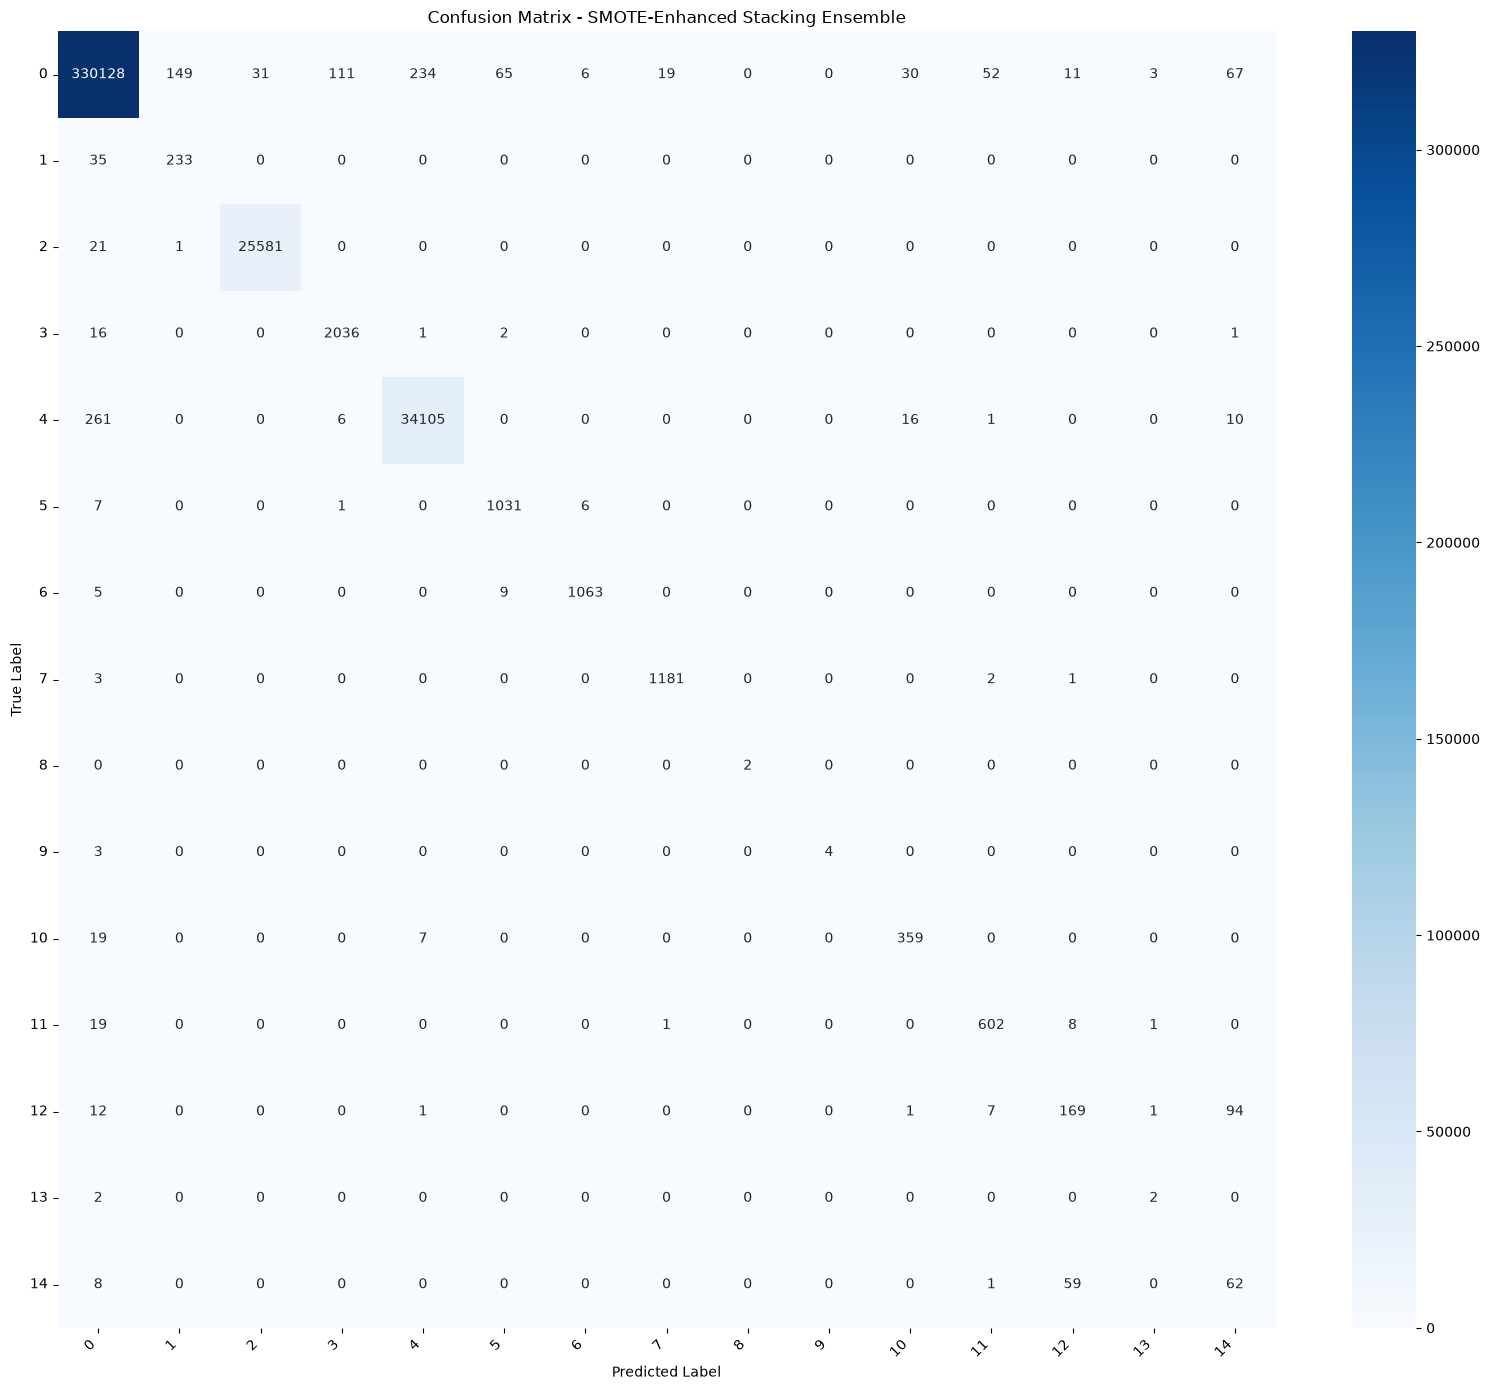


✓ Confusion matrix saved:
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/figures/Final_Stacking_ConfusionMatrix.png


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    stacking_pred
)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[str(x) for x in class_names_loaded],
    yticklabels=[str(x) for x in class_names_loaded]
)

plt.title(
    "Confusion Matrix - SMOTE-Enhanced Stacking Ensemble"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

FIGURE_DIR = PROJECT_DIR / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

cm_path = (
    FIGURE_DIR /
    "Final_Stacking_ConfusionMatrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("✓ Confusion matrix saved:")
print(cm_path)

In [18]:
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

final_metrics = pd.DataFrame([{
    "Model": "SMOTE-Enhanced Stacking Ensemble",
    "Accuracy": accuracy,
    "Weighted Precision": precision,
    "Weighted Recall": recall,
    "Weighted F1": f1,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Prediction Time (sec)": prediction_time
}])

metrics_path = (
    RESULTS_DIR /
    "Final_Stacking_Ensemble_Metrics.csv"
)

final_metrics.to_csv(
    metrics_path,
    index=False
)

print("✓ Final metrics saved:")
print(metrics_path)

display(final_metrics)

✓ Final metrics saved:
/srv/data/datasets/Network-Intrusion-Detection-System/Intrusion_Detection_System/results/Final_Stacking_Ensemble_Metrics.csv


,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1,Prediction Time (sec)
0,SMOTE-Enhanced Stacking Ensemble,0.996414,0.996732,0.996414,0.996538,0.83128,0.856287,0.834003,0.074933


In [19]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(
    y_test,
    stacking_pred
)

print("=" * 70)
print("BALANCED ACCURACY - STACKING ENSEMBLE")
print("=" * 70)

print(f"Balanced Accuracy : {balanced_acc:.6f}")
print(f"Balanced Accuracy : {balanced_acc * 100:.4f}%")

BALANCED ACCURACY - STACKING ENSEMBLE
Balanced Accuracy : 0.856287
Balanced Accuracy : 85.6287%


In [20]:
import pandas as pd
import numpy as np

print("=" * 70)
print("SMOTE CLASS DISTRIBUTION ANALYSIS")
print("=" * 70)

# Original training labels
original_counts = pd.Series(y_train).value_counts().sort_index()

# SMOTE training labels
smote_counts = pd.Series(y_train_smote).value_counts().sort_index()

comparison = pd.DataFrame({
    "Original Training": original_counts,
    "After SMOTE": smote_counts
}).fillna(0)

comparison["Increase"] = (
    comparison["After SMOTE"] -
    comparison["Original Training"]
)

comparison["Increase %"] = np.where(
    comparison["Original Training"] > 0,
    (
        (comparison["After SMOTE"] -
         comparison["Original Training"])
        / comparison["Original Training"]
    ) * 100,
    0
)

print(comparison)

SMOTE CLASS DISTRIBUTION ANALYSIS


NameError: name 'y_train' is not defined